# 💎 Diamonds — Production-Grade ML Pipeline
## FAANG-Level: EDA · Feature Engineering · 5 Models · SHAP · LIME · Granular Report

| Property | Value |
|---|---|
| Dataset | Diamonds.csv — 53,940 records, 10 features |
| Task | 4-class Price Tier Classification |
| Models | Random Forest · Extra Trees · Hist GradBoost · MLP · Logistic Regression |
| XAI | Kernel SHAP (from scratch) · LIME (from scratch) · Permutation Importance |
| Output | 13 figures + granular report + engineered dataset |

> **To run:** Upload `Diamonds.csv` when prompted in Cell 1, then `Runtime → Run All`


In [1]:
# ── 0. Install & Imports ─────────────────────────────────────────────────
# All dependencies are standard — no external XAI libraries needed.
# SHAP and LIME are implemented from scratch below.

import os, json, pickle, time, warnings
from math import comb
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, spearmanr, linregress

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import (StandardScaler, RobustScaler, PowerTransformer,
                                    label_binarize)
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               HistGradientBoostingClassifier)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              roc_auc_score, roc_curve, f1_score, log_loss,
                              precision_recall_curve, average_precision_score,
                              r2_score)
from sklearn.decomposition import PCA
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

# ── Global colour palette ─────────────────────────────────────────────────
GRN    = ['#0D2B1F','#1A3D2B','#2D6A4F','#40916C','#52B788',
          '#74C69D','#95D5B2','#B7E4C7','#D8F3DC','#F0FFF4']
ACCENT = '#FF6B35'
DARK   = '#0D1B13'
TIER_NAMES  = ['Budget', 'Mid-Low', 'Mid-High', 'Premium']
TIER_COLORS = [GRN[2], GRN[4], GRN[6], GRN[8]]

plt.rcParams.update({
    'figure.facecolor': '#FAFCFA',
    'axes.facecolor':   '#F4F9F4',
    'axes.edgecolor':   '#C8DFC8',
    'axes.grid':        True,
    'grid.color':       '#E0EEE0',
    'grid.linewidth':   0.6,
    'font.family':      'DejaVu Sans',
    'figure.dpi':       120,
})
os.makedirs('outputs', exist_ok=True)
print("✅ All imports OK")


✅ All imports OK


## 📂 1 — Load & Validate Dataset

In [2]:
# Upload Diamonds.csv
try:
    from google.colab import files
    print("Please upload Diamonds.csv ...")
    uploaded = files.upload()
    CSV_PATH = list(uploaded.keys())[0]
except Exception:
    CSV_PATH = 'Diamonds.csv'   # already present locally

df = pd.read_csv(CSV_PATH)
assert df.isnull().sum().sum() == 0, "Unexpected nulls!"
print(f"✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Price : ${df['price'].min():,} – ${df['price'].max():,}")
print(f"   Carat : {df['carat'].min():.2f} – {df['carat'].max():.2f}")
df.describe().round(3)


Please upload Diamonds.csv ...


Saving Diamonds.csv to Diamonds (1).csv
✅ Loaded: 53,940 rows × 10 columns
   Price : $326 – $18,823
   Carat : 0.20 – 5.01


,carat,depth,table,x,y,z,price
count,53940.000,53940.000,53940.000,53940.000,53940.000,53940.000,53940.00
mean,0.798,61.749,57.457,5.731,5.735,3.539,3932.80
std,0.474,1.433,2.234,1.122,1.142,0.706,3989.44
min,0.200,43.000,43.000,0.000,0.000,0.000,326.00
25%,0.400,61.000,56.000,4.710,4.720,2.910,950.00
50%,0.700,61.800,57.000,5.700,5.710,3.530,2401.00
75%,1.040,62.500,59.000,6.540,6.540,4.040,5324.25
max,5.010,79.000,95.000,10.740,58.900,31.800,18823.00


## 🔍 2 — Exploratory Data Analysis

In [3]:
# Statistical tests
print("── Statistical significance tests ──────────────────────")
for cat in ['cut', 'color', 'clarity']:
    groups = [df[df[cat]==v]['price'].values for v in df[cat].unique()]
    H, p   = kruskal(*groups)
    print(f"  Kruskal-Wallis price~{cat:8s}: H={H:8.1f}  p={p:.2e}")
r, p = spearmanr(df['carat'], df['price'])
print(f"  Spearman carat↔price: ρ={r:.4f}  p={p:.2e}")


── Statistical significance tests ──────────────────────
  Kruskal-Wallis price~cut     : H=   978.6  p=1.53e-210
  Kruskal-Wallis price~color   : H=  1335.6  p=2.16e-285
  Kruskal-Wallis price~clarity : H=  2718.2  p=0.00e+00
  Spearman carat↔price: ρ=0.9629  p=0.00e+00


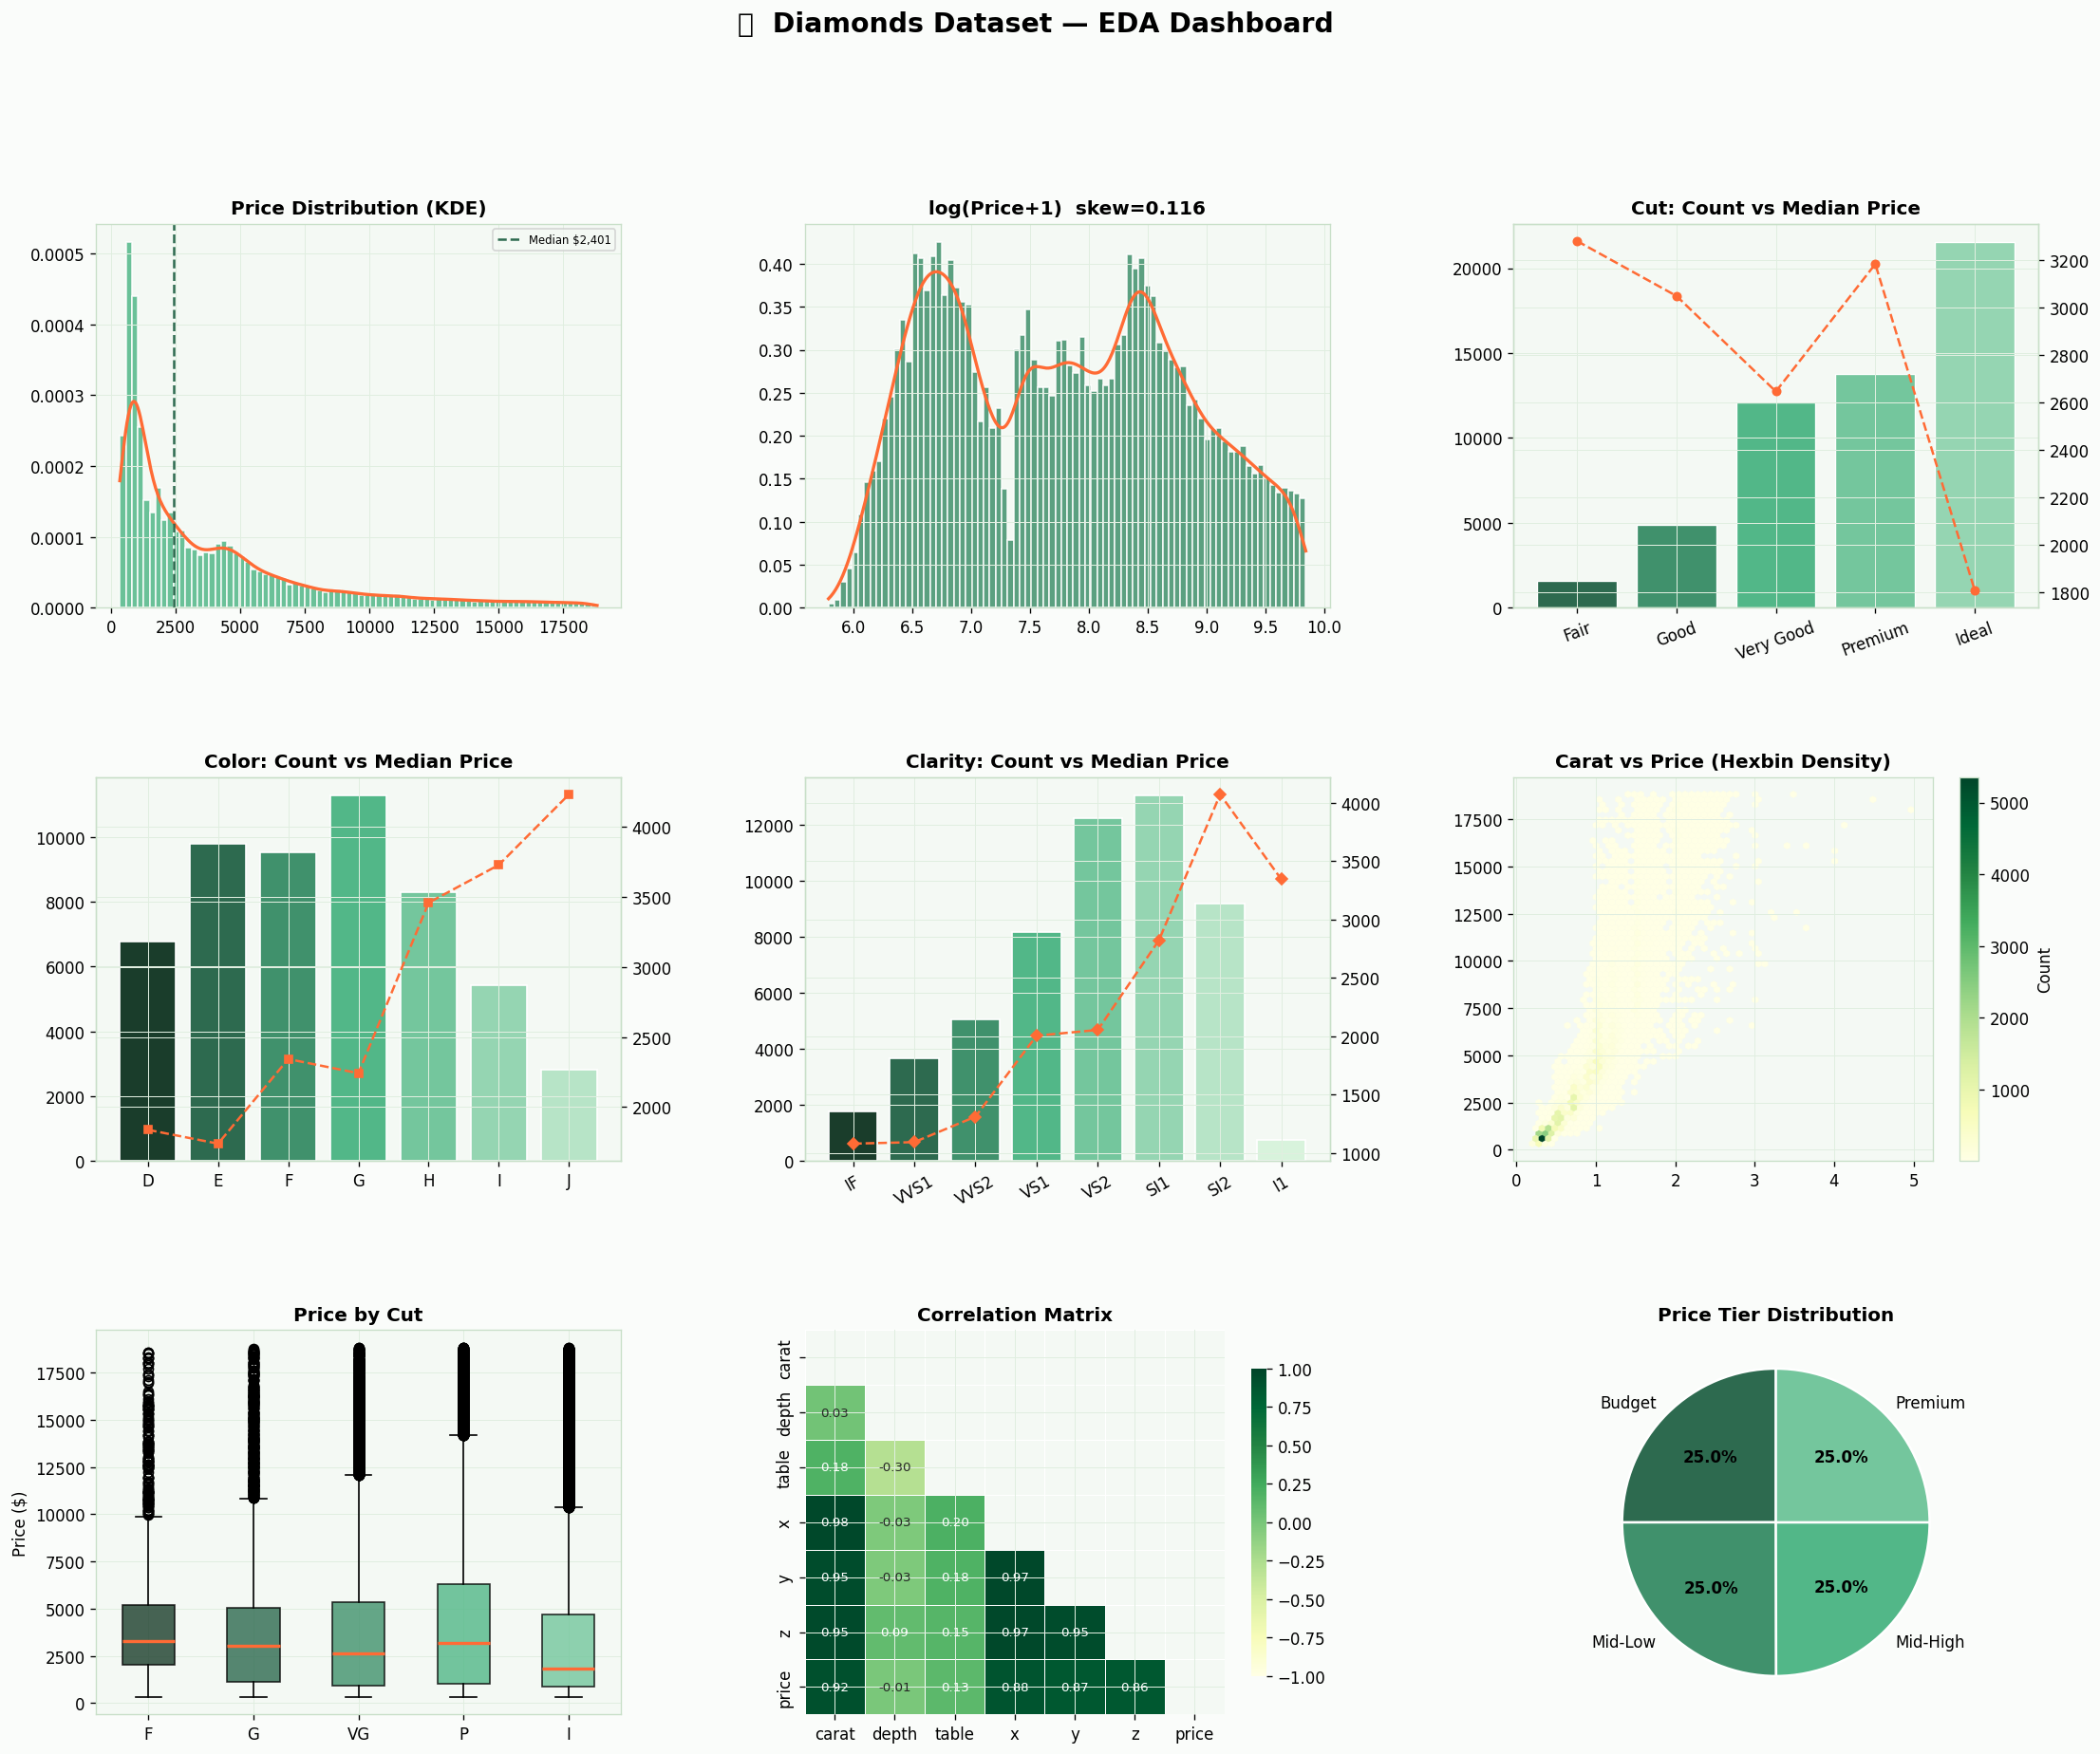

✅ Fig 01 — EDA Dashboard


In [4]:
# ── 9-panel EDA Dashboard ────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 17))
fig.patch.set_facecolor('#FAFCFA')
fig.suptitle('💎  Diamonds Dataset — EDA Dashboard', fontsize=17, fontweight='bold', y=0.99)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.44, wspace=0.35)

cut_order   = ['Fair','Good','Very Good','Premium','Ideal']
color_order = list('DEFGHIJ')
cl_order    = [c for c in ['IF','VVS1','VVS2','VS1','VS2','SI1','SI2','I1'] if c in df['clarity'].unique()]
samp        = df.sample(3000, random_state=42)

# Price KDE
ax1 = fig.add_subplot(gs[0,0])
ax1.hist(df['price'], bins=80, color=GRN[4], edgecolor='white', lw=0.4, density=True, alpha=0.85)
kde_x = np.linspace(df['price'].min(), df['price'].max(), 400)
ax1.plot(kde_x, stats.gaussian_kde(df['price'])(kde_x), color=ACCENT, lw=2)
ax1.axvline(df['price'].median(), color=GRN[2], lw=1.5, ls='--', label=f"Median ${df['price'].median():,.0f}")
ax1.set_title('Price Distribution (KDE)', fontweight='bold'); ax1.legend(fontsize=7)

# log(price)
ax2 = fig.add_subplot(gs[0,1])
lp = np.log1p(df['price'])
ax2.hist(lp, bins=80, color=GRN[3], edgecolor='white', lw=0.4, density=True, alpha=0.85)
ax2.plot(np.linspace(lp.min(),lp.max(),400), stats.gaussian_kde(lp)(np.linspace(lp.min(),lp.max(),400)), color=ACCENT, lw=2)
ax2.set_title(f'log(Price+1)  skew={stats.skew(lp):.3f}', fontweight='bold')

# Cut: count + median price
ax3 = fig.add_subplot(gs[0,2])
cc  = df['cut'].value_counts().reindex(cut_order)
cm_ = [df[df['cut']==c]['price'].median() for c in cut_order]
bars3 = ax3.bar(cut_order, cc, color=GRN[2:7], edgecolor='white', lw=0.8)
ax3r  = ax3.twinx()
ax3r.plot(cut_order, cm_, 'o--', color=ACCENT, lw=1.5, ms=5)
ax3.set_title('Cut: Count vs Median Price', fontweight='bold')
ax3.tick_params(axis='x', rotation=20)

# Color
ax4 = fig.add_subplot(gs[1,0])
ax4.bar(color_order, [df[df['color']==c].shape[0] for c in color_order], color=GRN[1:8], edgecolor='white')
ax4r = ax4.twinx()
ax4r.plot(color_order, [df[df['color']==c]['price'].median() for c in color_order], 's--', color=ACCENT, lw=1.5, ms=5)
ax4.set_title('Color: Count vs Median Price', fontweight='bold')

# Clarity
ax5 = fig.add_subplot(gs[1,1])
ax5.bar(cl_order, [df[df['clarity']==c].shape[0] for c in cl_order], color=GRN[1:9], edgecolor='white')
ax5r = ax5.twinx()
ax5r.plot(cl_order, [df[df['clarity']==c]['price'].median() for c in cl_order], 'D--', color=ACCENT, lw=1.5, ms=5)
ax5.set_title('Clarity: Count vs Median Price', fontweight='bold'); ax5.tick_params(axis='x', rotation=30)

# Hexbin
ax6 = fig.add_subplot(gs[1,2])
hb  = ax6.hexbin(df['carat'], df['price'], gridsize=60, cmap='YlGn', mincnt=1, linewidths=0.2)
plt.colorbar(hb, ax=ax6, label='Count')
ax6.set_title('Carat vs Price (Hexbin Density)', fontweight='bold')

# Boxplots by cut
ax7 = fig.add_subplot(gs[2,0])
bp  = ax7.boxplot([df[df['cut']==c]['price'].values for c in cut_order],
                   labels=['F','G','VG','P','I'], patch_artist=True,
                   medianprops=dict(color=ACCENT, lw=2))
for patch, col in zip(bp['boxes'], GRN[1:6]):
    patch.set_facecolor(col); patch.set_alpha(0.8)
ax7.set_title('Price by Cut', fontweight='bold'); ax7.set_ylabel('Price ($)')

# Correlation heatmap
ax8 = fig.add_subplot(gs[2,1])
corr = df[['carat','depth','table','x','y','z','price']].corr()
sns.heatmap(corr, mask=np.triu(np.ones_like(corr,dtype=bool)), ax=ax8,
            cmap='YlGn', annot=True, fmt='.2f', linewidths=0.5,
            annot_kws={'size':8}, vmin=-1, vmax=1, cbar_kws={'shrink':0.8})
ax8.set_title('Correlation Matrix', fontweight='bold')

# Price tier pie (placeholder — will fill after engineering)
ax9 = fig.add_subplot(gs[2,2])
q1_, q2_, q3_ = df['price'].quantile([0.25, 0.5, 0.75])
temp_tier = pd.cut(df['price'], bins=[-np.inf,q1_,q2_,q3_,np.inf], labels=TIER_NAMES)
tc_ = temp_tier.value_counts().reindex(TIER_NAMES)
wedges, texts, autotexts = ax9.pie(tc_, labels=TIER_NAMES, colors=GRN[2:6],
    autopct='%1.1f%%', startangle=90, wedgeprops=dict(edgecolor='white', lw=1.5))
for at in autotexts: at.set_fontweight('bold')
ax9.set_title('Price Tier Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/fig01_eda_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Fig 01 — EDA Dashboard")


## ⚙️ 3 — Feature Engineering (26 Features)

In [5]:
df2 = df.copy()

# ── Ordinal encodings ─────────────────────────────────────────────────────
cut_map     = {'Fair':1,'Good':2,'Very Good':3,'Premium':4,'Ideal':5}
color_map   = {'J':1,'I':2,'H':3,'G':4,'F':5,'E':6,'D':7}
clarity_map = {'I1':1,'SI2':2,'SI1':3,'VS2':4,'VS1':5,'VVS2':6,'VVS1':7,'IF':8}
df2['cut_enc']     = df2['cut'].map(cut_map)
df2['color_enc']   = df2['color'].map(color_map)
df2['clarity_enc'] = df2['clarity'].map(clarity_map)

# ── Geometry / Physics ────────────────────────────────────────────────────
df2['volume']          = df2['x'] * df2['y'] * df2['z']
df2['density_proxy']   = df2['carat'] / df2['volume'].clip(lower=0.001)
df2['table_depth_rat'] = df2['table'] / df2['depth']
df2['xy_ratio']        = df2['x'] / df2['y'].clip(lower=0.001)
df2['xz_ratio']        = df2['x'] / df2['z'].clip(lower=0.001)
df2['yz_ratio']        = df2['y'] / df2['z'].clip(lower=0.001)
df2['girdle_area']     = np.pi * ((df2['x'] + df2['y']) / 4) ** 2
df2['depth_pct_calc']  = df2['z'] / ((df2['x'] + df2['y']) / 2).clip(lower=0.001) * 100

# ── Quality composites ────────────────────────────────────────────────────
df2['4c_score']      = df2['cut_enc'] + df2['color_enc'] + df2['clarity_enc']
df2['cut_color']     = df2['cut_enc']  * df2['color_enc']
df2['cut_clarity']   = df2['cut_enc']  * df2['clarity_enc']
df2['color_clarity'] = df2['color_enc'] * df2['clarity_enc']
df2['4c_product']    = df2['cut_enc']  * df2['color_enc'] * df2['clarity_enc']

# ── Log / polynomial transforms ───────────────────────────────────────────
df2['log_carat']   = np.log1p(df2['carat'])
df2['log_volume']  = np.log1p(df2['volume'])
df2['carat_sq']    = df2['carat'] ** 2
df2['carat_x_4c']  = df2['carat'] * df2['4c_score']

# ── Target ────────────────────────────────────────────────────────────────
q1, q2, q3  = df2['price'].quantile([0.25, 0.5, 0.75]).values
df2['price_tier'] = pd.cut(df2['price'], bins=[-np.inf,q1,q2,q3,np.inf],
                             labels=[0,1,2,3]).astype(int)

FEATURE_COLS = [
    'carat','depth','table','x','y','z',
    'cut_enc','color_enc','clarity_enc',
    'volume','density_proxy','table_depth_rat',
    'xy_ratio','xz_ratio','yz_ratio',
    'girdle_area','depth_pct_calc',
    '4c_score','cut_color','cut_clarity','color_clarity','4c_product',
    'log_carat','log_volume','carat_sq','carat_x_4c',
]

print(f"✅ Feature Engineering complete: {len(FEATURE_COLS)} features")
print(f"   Quartile boundaries: Q1=${q1:.0f} | Q2=${q2:.0f} | Q3=${q3:.0f}")
for i,t in enumerate(TIER_NAMES):
    n=(df2['price_tier']==i).sum(); print(f"   {t:10s}: {n:,} ({n/len(df2)*100:.1f}%)")


✅ Feature Engineering complete: 26 features
   Quartile boundaries: Q1=$950 | Q2=$2401 | Q3=$5324
   Budget    : 13,490 (25.0%)
   Mid-Low   : 13,495 (25.0%)
   Mid-High  : 13,470 (25.0%)
   Premium   : 13,485 (25.0%)


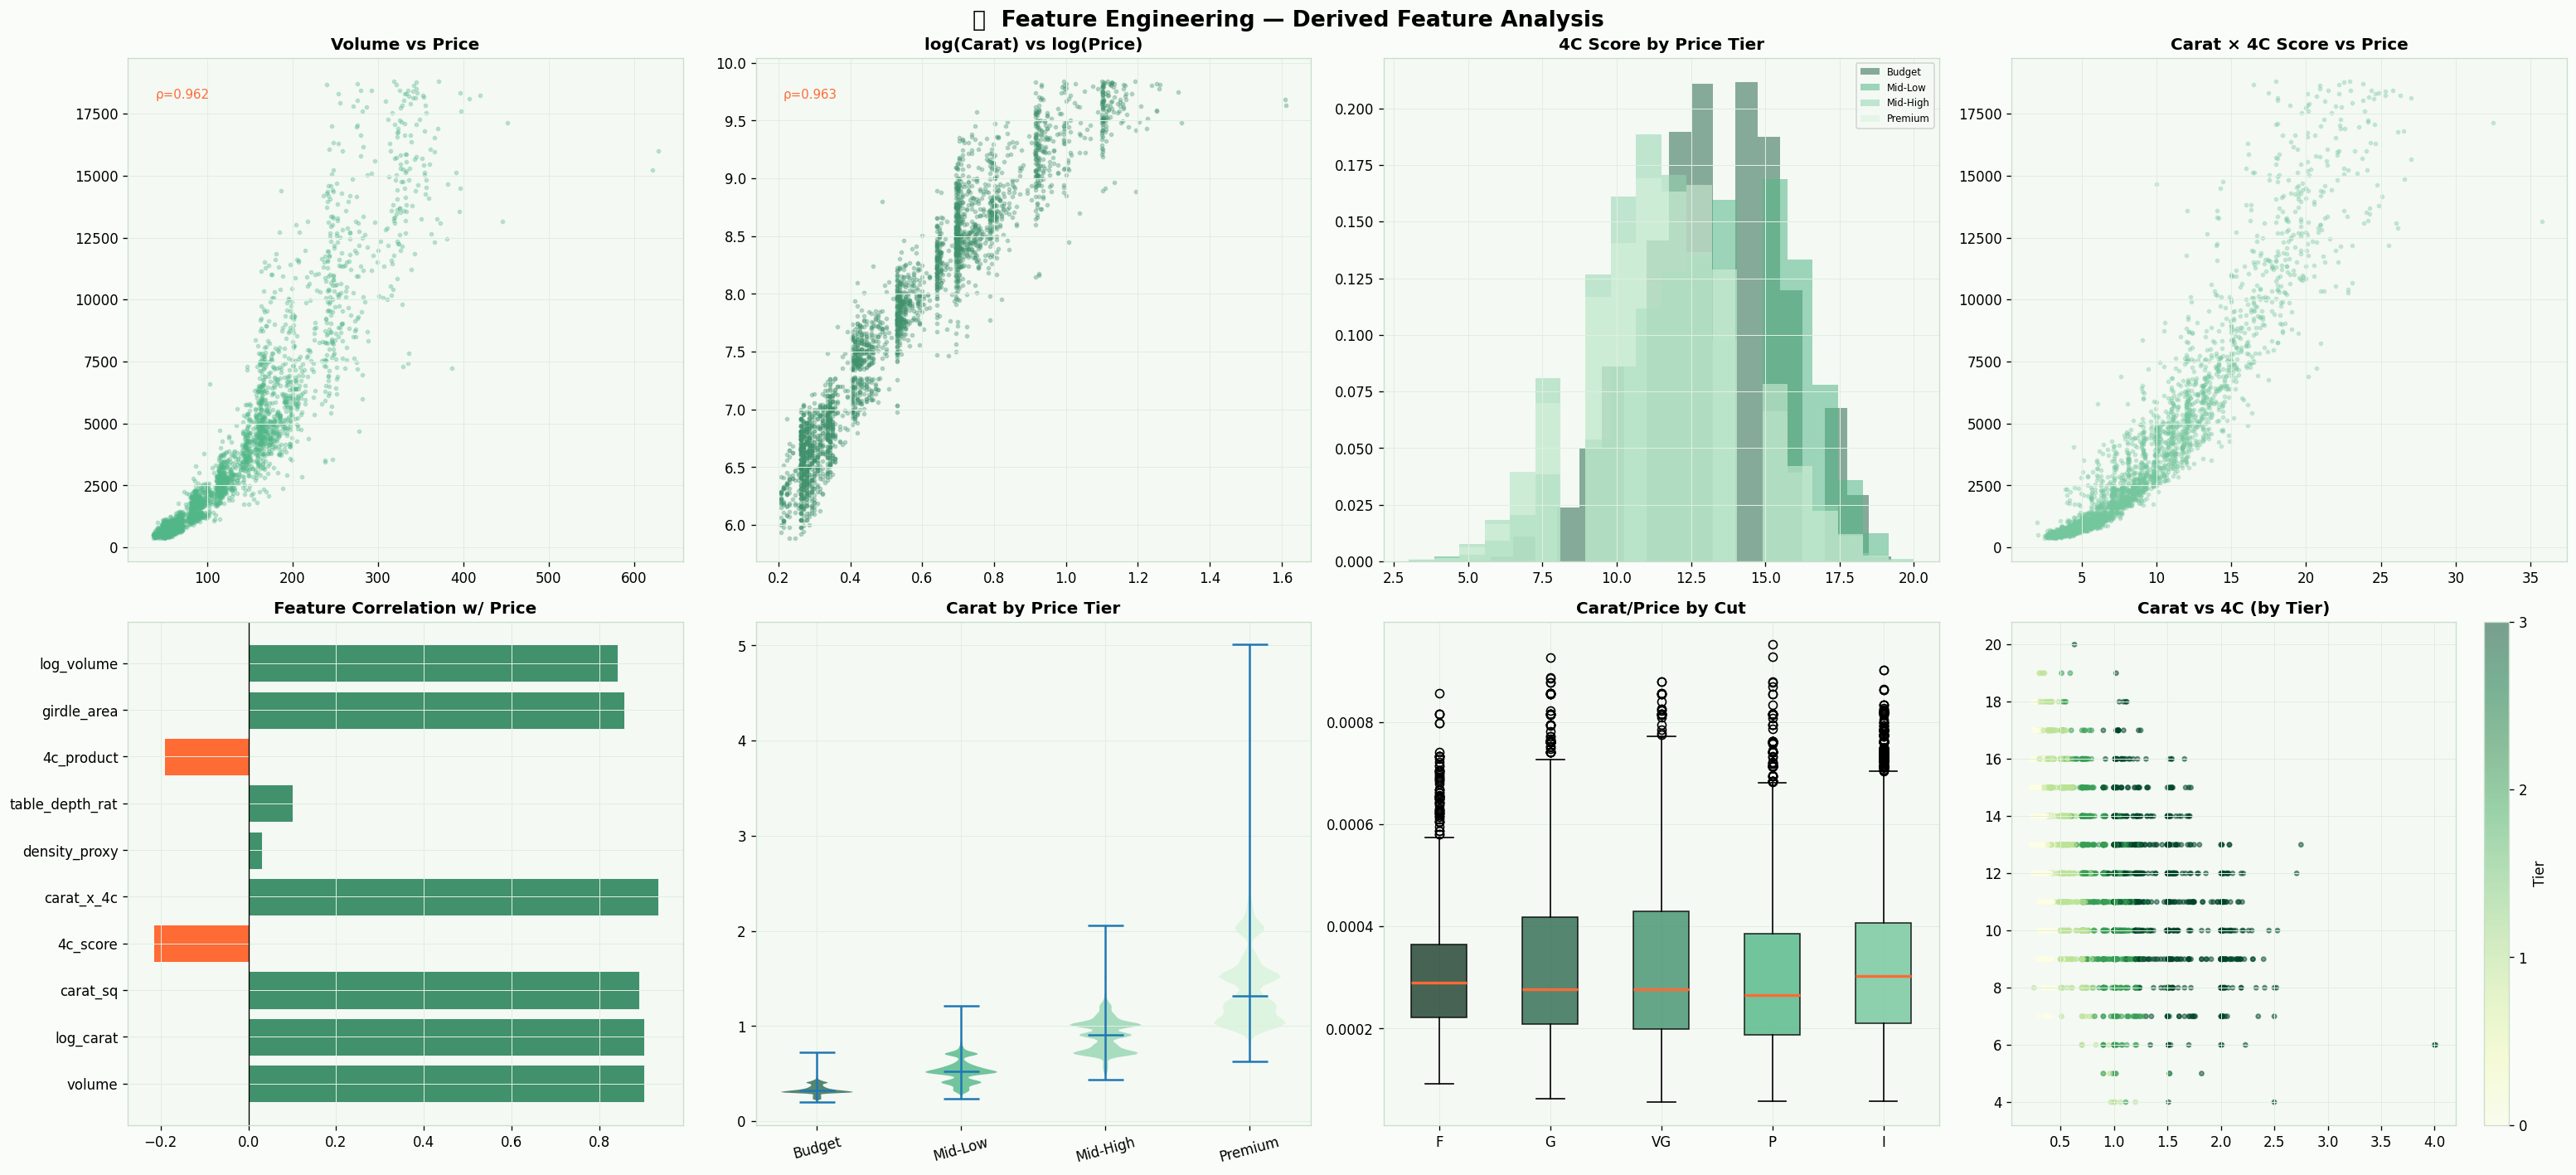

✅ Fig 02 — Feature Engineering


In [6]:
# ── Feature Engineering Visualisation ────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(26, 12))
fig.patch.set_facecolor('#FAFCFA')
fig.suptitle('💎  Feature Engineering — Derived Feature Analysis', fontsize=16, fontweight='bold')
s = df2.sample(3000, random_state=42)

# Volume vs price
axes[0,0].scatter(s['volume'], s['price'], alpha=0.3, s=6, c=GRN[4])
axes[0,0].set_title('Volume vs Price', fontweight='bold')
r,_ = spearmanr(df2['volume'], df2['price'])
axes[0,0].text(0.05, 0.92, f'ρ={r:.3f}', transform=axes[0,0].transAxes, color=ACCENT, fontsize=9)

# log carat vs log price
axes[0,1].scatter(s['log_carat'], np.log1p(s['price']), alpha=0.3, s=6, c=GRN[3])
axes[0,1].set_title('log(Carat) vs log(Price)', fontweight='bold')
r2,_ = spearmanr(df2['log_carat'], np.log1p(df2['price']))
axes[0,1].text(0.05, 0.92, f'ρ={r2:.3f}', transform=axes[0,1].transAxes, color=ACCENT, fontsize=9)

# 4C score by tier
for i,(tier,tc) in enumerate(zip(TIER_NAMES, [GRN[2],GRN[4],GRN[6],GRN[8]])):
    d = df2[df2['price_tier']==i]['4c_score']
    axes[0,2].hist(d, bins=20, alpha=0.55, color=tc, label=tier, density=True)
axes[0,2].set_title('4C Score by Price Tier', fontweight='bold'); axes[0,2].legend(fontsize=7)

# Carat×4C vs price
axes[0,3].scatter(s['carat_x_4c'], s['price'], alpha=0.3, s=6, c=GRN[5])
axes[0,3].set_title('Carat × 4C Score vs Price', fontweight='bold')

# Engineered feature correlations
eng_f = ['volume','log_carat','carat_sq','4c_score','carat_x_4c','density_proxy',
          'table_depth_rat','4c_product','girdle_area','log_volume']
corrs = [df2[f].corr(df2['price']) for f in eng_f]
axes[1,0].barh(eng_f, corrs, color=[GRN[3] if c>0 else ACCENT for c in corrs], edgecolor='white', lw=0.5)
axes[1,0].axvline(0, color='k', lw=0.8); axes[1,0].set_title('Feature Correlation w/ Price', fontweight='bold')

# Violin: carat by tier
parts = axes[1,1].violinplot([df2[df2['price_tier']==i]['carat'].values for i in range(4)],
                               positions=range(4), showmedians=True)
for pc, c in zip(parts['bodies'], [GRN[2],GRN[4],GRN[6],GRN[8]]):
    pc.set_facecolor(c); pc.set_alpha(0.8)
axes[1,1].set_xticks(range(4)); axes[1,1].set_xticklabels(TIER_NAMES, rotation=15)
axes[1,1].set_title('Carat by Price Tier', fontweight='bold')

# Price per carat by cut
data_ppc = [df2[df2['cut']==c]['carat'].div(df2[df2['cut']==c]['price']).values
             for c in ['Fair','Good','Very Good','Premium','Ideal']]
bp2 = axes[1,2].boxplot(data_ppc, labels=['F','G','VG','P','I'], patch_artist=True,
                          medianprops=dict(color=ACCENT, lw=2))
for patch,c in zip(bp2['boxes'],GRN[1:6]): patch.set_facecolor(c); patch.set_alpha(0.8)
axes[1,2].set_title('Carat/Price by Cut', fontweight='bold')

# 2D scatter: carat vs 4c_score coloured by tier
sc_ = axes[1,3].scatter(s['carat'], s['4c_score'], c=s['price_tier'],
                          cmap='YlGn', s=10, alpha=0.5)
plt.colorbar(sc_, ax=axes[1,3], label='Tier', ticks=[0,1,2,3])
axes[1,3].set_title('Carat vs 4C (by Tier)', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/fig02_feature_engineering.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Fig 02 — Feature Engineering")


## 🔀 4 — Train / Val / Test Split & Scaling

In [7]:
X = df2[FEATURE_COLS].values.astype(np.float64)
y = df2['price_tier'].values

# 60 / 20 / 20 stratified split
X_tv,  X_test,  y_tv,  y_test  = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train,X_val,  y_train,y_val  = train_test_split(X_tv, y_tv, test_size=0.25, random_state=42, stratify=y_tv)

scaler = StandardScaler().fit(X_train)
pt     = PowerTransformer(method='yeo-johnson').fit(X_train)
X_tr_s, X_te_s = scaler.transform(X_train), scaler.transform(X_test)
X_tr_p, X_te_p = pt.transform(X_train), pt.transform(X_test)

print(f"Train : {X_train.shape}  |  Val : {X_val.shape}  |  Test : {X_test.shape}")
print(f"Class counts (test): { {t: (y_test==i).sum() for i,t in enumerate(TIER_NAMES)} }")


Train : (32364, 26)  |  Val : (10788, 26)  |  Test : (10788, 26)
Class counts (test): {'Budget': np.int64(2698), 'Mid-Low': np.int64(2699), 'Mid-High': np.int64(2694), 'Premium': np.int64(2697)}


## 🤖 5 — Multi-Model Training

In [8]:
models_cfg = {
    'Random Forest':       (RandomForestClassifier(
                               n_estimators=200, max_features='sqrt', n_jobs=-1,
                               random_state=42, class_weight='balanced'), False),
    'Extra Trees':         (ExtraTreesClassifier(
                               n_estimators=200, max_features='sqrt', n_jobs=-1,
                               random_state=42, class_weight='balanced'), False),
    'Hist Grad Boost':     (HistGradientBoostingClassifier(
                               max_iter=300, learning_rate=0.08, max_depth=6,
                               l2_regularization=0.1, random_state=42), False),
    'MLP Neural Net':      (MLPClassifier(
                               hidden_layer_sizes=(256,128,64), activation='relu',
                               solver='adam', alpha=1e-4, batch_size=512,
                               learning_rate_init=1e-3, max_iter=300,
                               early_stopping=True, random_state=42), 'power'),
    'Logistic Regression': (LogisticRegression(
                               C=1.0, max_iter=500, solver='saga',
                               random_state=42, n_jobs=-1), 'std'),
}

results = {}
print(f"{'Model':25s} {'Acc':>8} {'F1':>8} {'AUC':>8} {'LogLoss':>9}")
print("─" * 58)

for name, (m, sc) in models_cfg.items():
    Xtr = X_tr_p if sc=='power' else (X_tr_s if sc=='std' else X_train)
    Xte = X_te_p if sc=='power' else (X_te_s if sc=='std' else X_test)
    t0  = time.time()
    m.fit(Xtr, y_train)
    yp   = m.predict(Xte)
    ypr  = m.predict_proba(Xte)
    acc  = accuracy_score(y_test, yp)
    f1_w = f1_score(y_test, yp, average='weighted')
    auc  = roc_auc_score(y_test, ypr, multi_class='ovr', average='weighted')
    ll   = log_loss(y_test, ypr)
    results[name] = {
        'model': m, 'acc': acc, 'f1': f1_w, 'auc': auc, 'll': ll,
        'y_pred': yp, 'y_prob': ypr,
        'cm': confusion_matrix(y_test, yp),
        'report': classification_report(y_test, yp, target_names=TIER_NAMES, output_dict=True),
        'scale': sc,
    }
    print(f"{name:25s} {acc:>8.4f} {f1_w:>8.4f} {auc:>8.4f} {ll:>9.4f}  [{time.time()-t0:.0f}s]")

best_name  = max(results, key=lambda n: results[n]['auc'])
best       = results[best_name]
print(f"\n🏆 Best model (by AUC): {best_name}  AUC={best['auc']:.4f}  Acc={best['acc']:.4f}")


Model                          Acc       F1      AUC   LogLoss
──────────────────────────────────────────────────────────
Random Forest               0.9427   0.9427   0.9951    0.1634  [19s]
Extra Trees                 0.9410   0.9410   0.9940    0.2026  [8s]
Hist Grad Boost             0.9435   0.9436   0.9954    0.1439  [5s]
MLP Neural Net              0.9359   0.9359   0.9945    0.1614  [30s]
Logistic Regression         0.9153   0.9154   0.9907    0.2182  [29s]

🏆 Best model (by AUC): Hist Grad Boost  AUC=0.9954  Acc=0.9435


## 📊 6 — Comparative Analysis

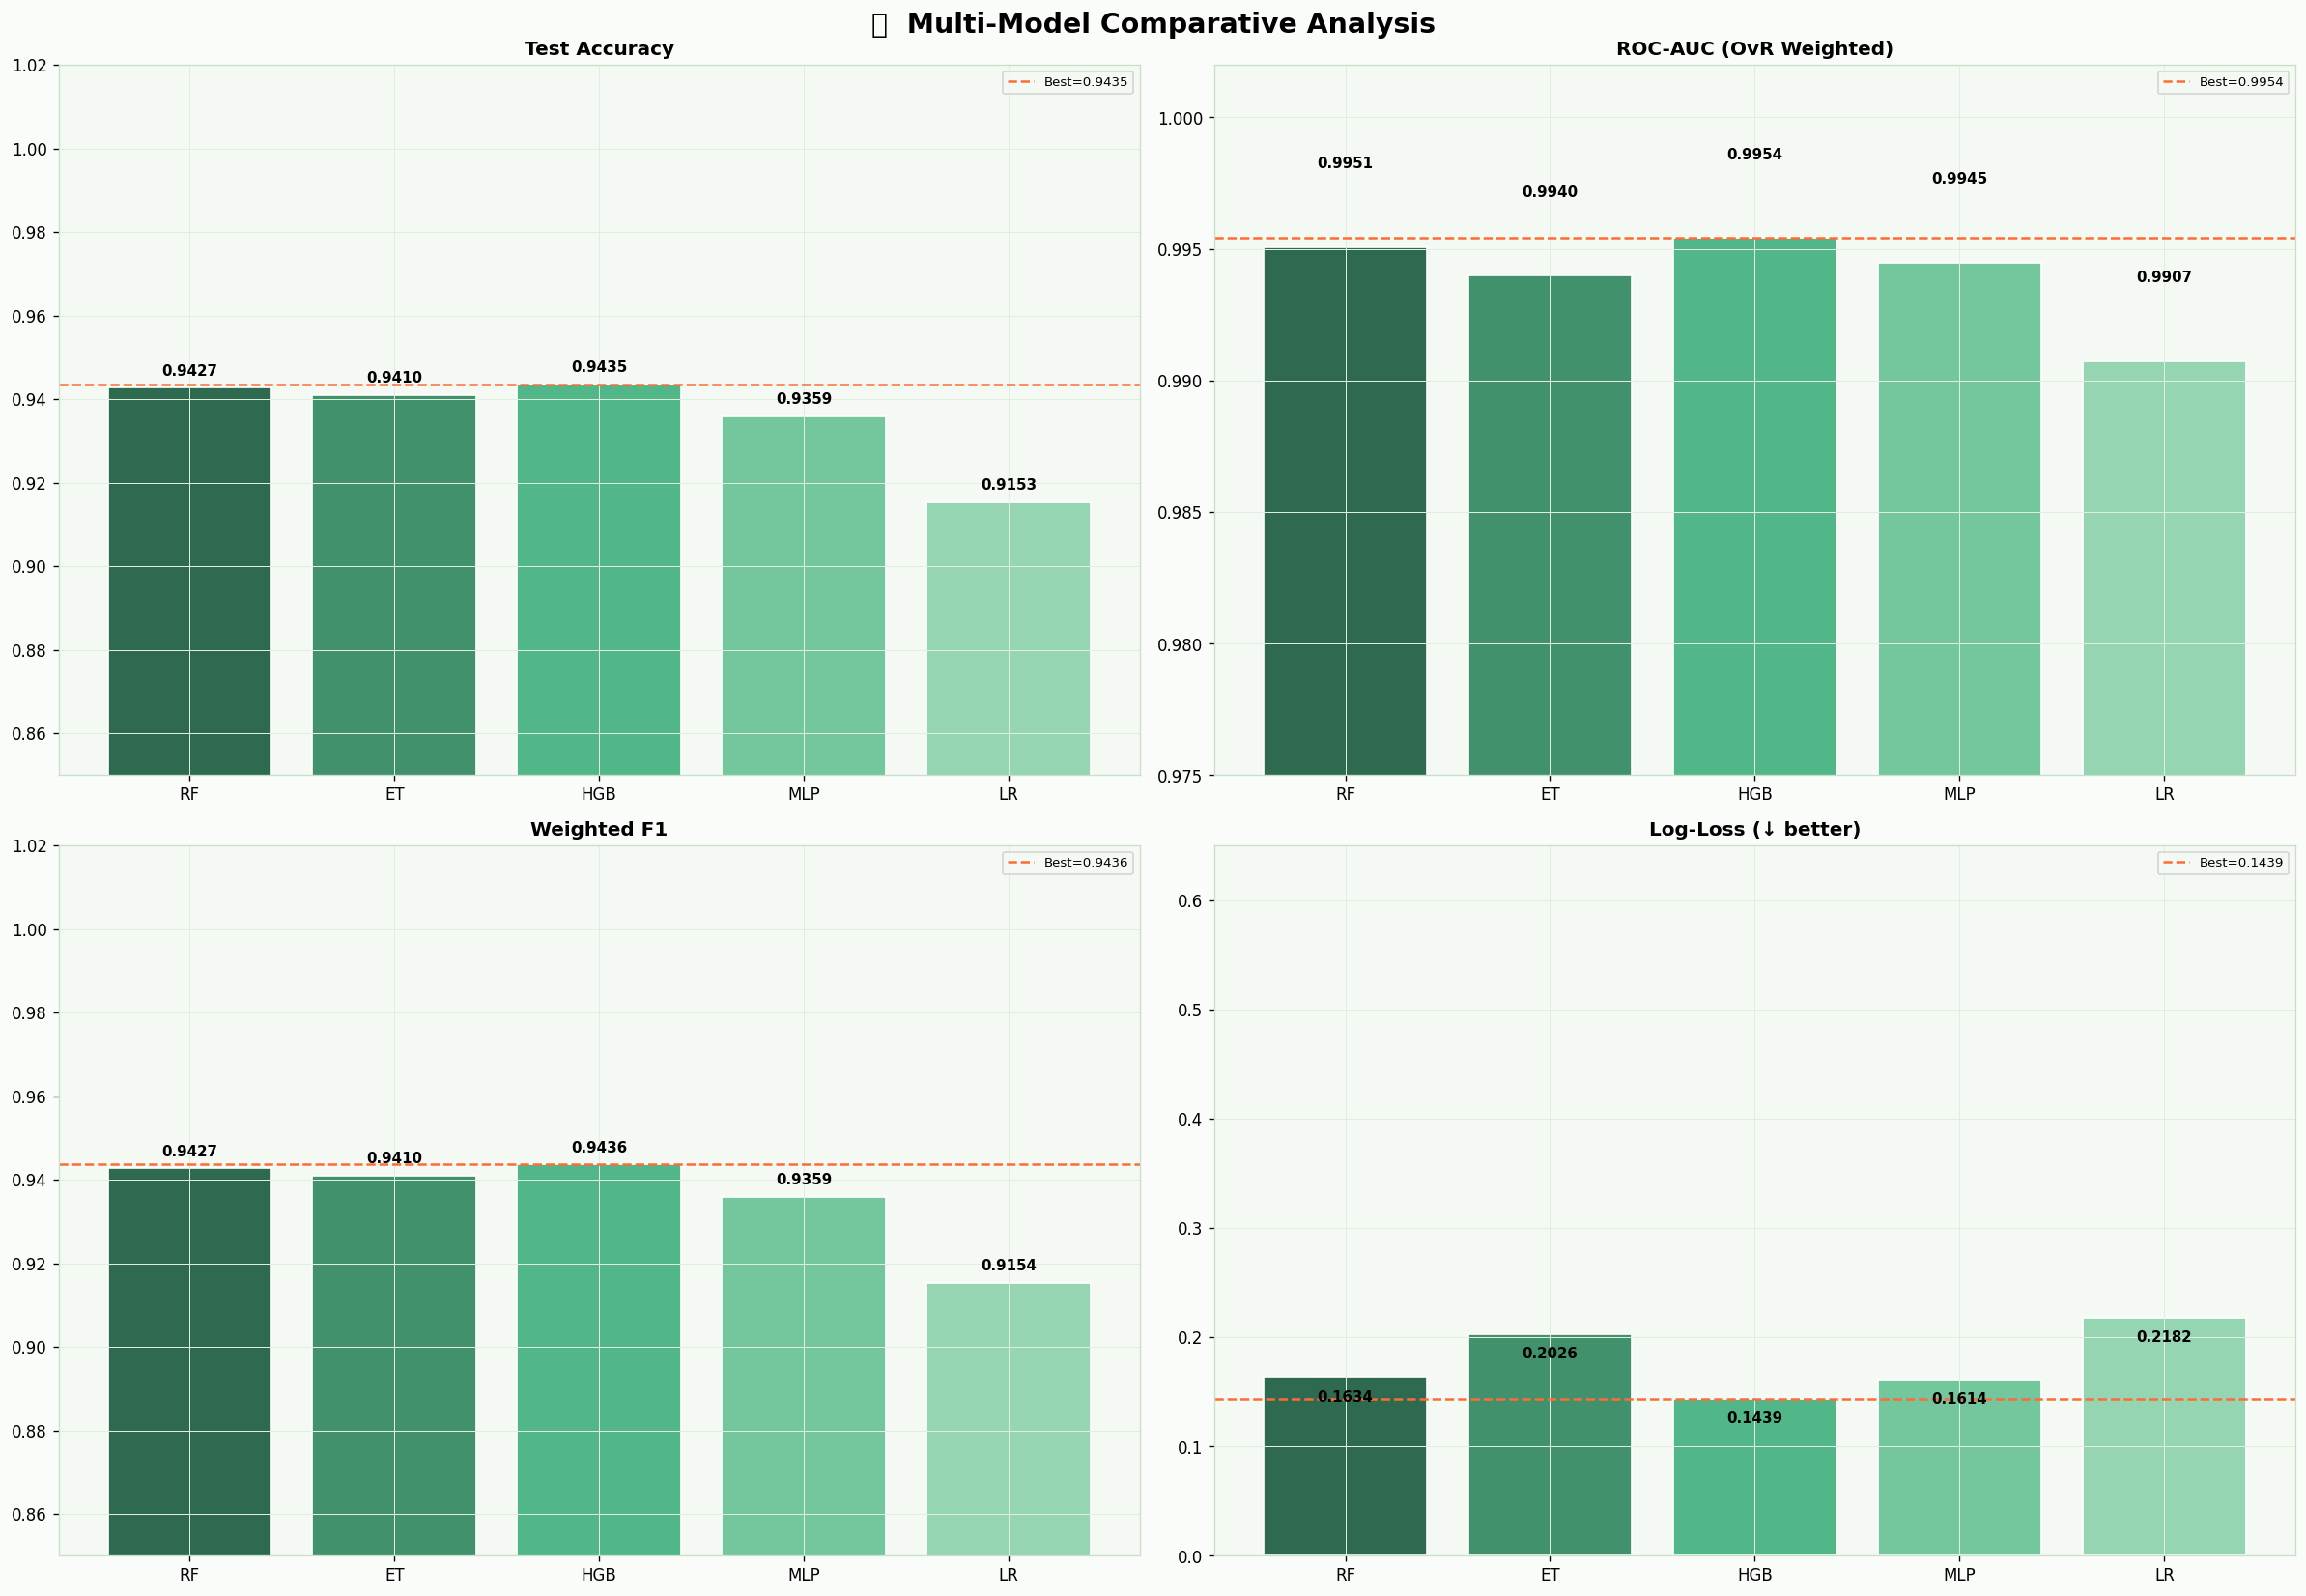

✅ Fig 03 — Model Comparison


In [9]:
mn   = list(results.keys())
sn   = ['RF', 'ET', 'HGB', 'MLP', 'LR']
accs = [results[n]['acc'] for n in mn]
f1s  = [results[n]['f1']  for n in mn]
aucs = [results[n]['auc'] for n in mn]
lls  = [results[n]['ll']  for n in mn]
bar_colors = GRN[2:7]
xp = np.arange(5)

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.patch.set_facecolor('#FAFCFA')
fig.suptitle('💎  Multi-Model Comparative Analysis', fontsize=17, fontweight='bold')

for ax, vals, title, ylim, better in zip(
    axes.flat,
    [accs, aucs, f1s, lls],
    ['Test Accuracy', 'ROC-AUC (OvR Weighted)', 'Weighted F1', 'Log-Loss (↓ better)'],
    [(0.85,1.02),(0.975,1.002),(0.85,1.02),(0.0,0.65)],
    ['max','max','max','min']):
    bars = ax.bar(sn, vals, color=bar_colors, edgecolor='white', lw=1)
    bv   = max(vals) if better == 'max' else min(vals)
    ax.axhline(bv, color=ACCENT, ls='--', lw=1.5, label=f'Best={bv:.4f}')
    ax.set_title(title, fontweight='bold'); ax.set_ylim(ylim); ax.legend(fontsize=8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() + (0.003 if better=='max' else -0.022),
                f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/fig03_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Fig 03 — Model Comparison")


## 🏆 7 — Best Model Deep Evaluation

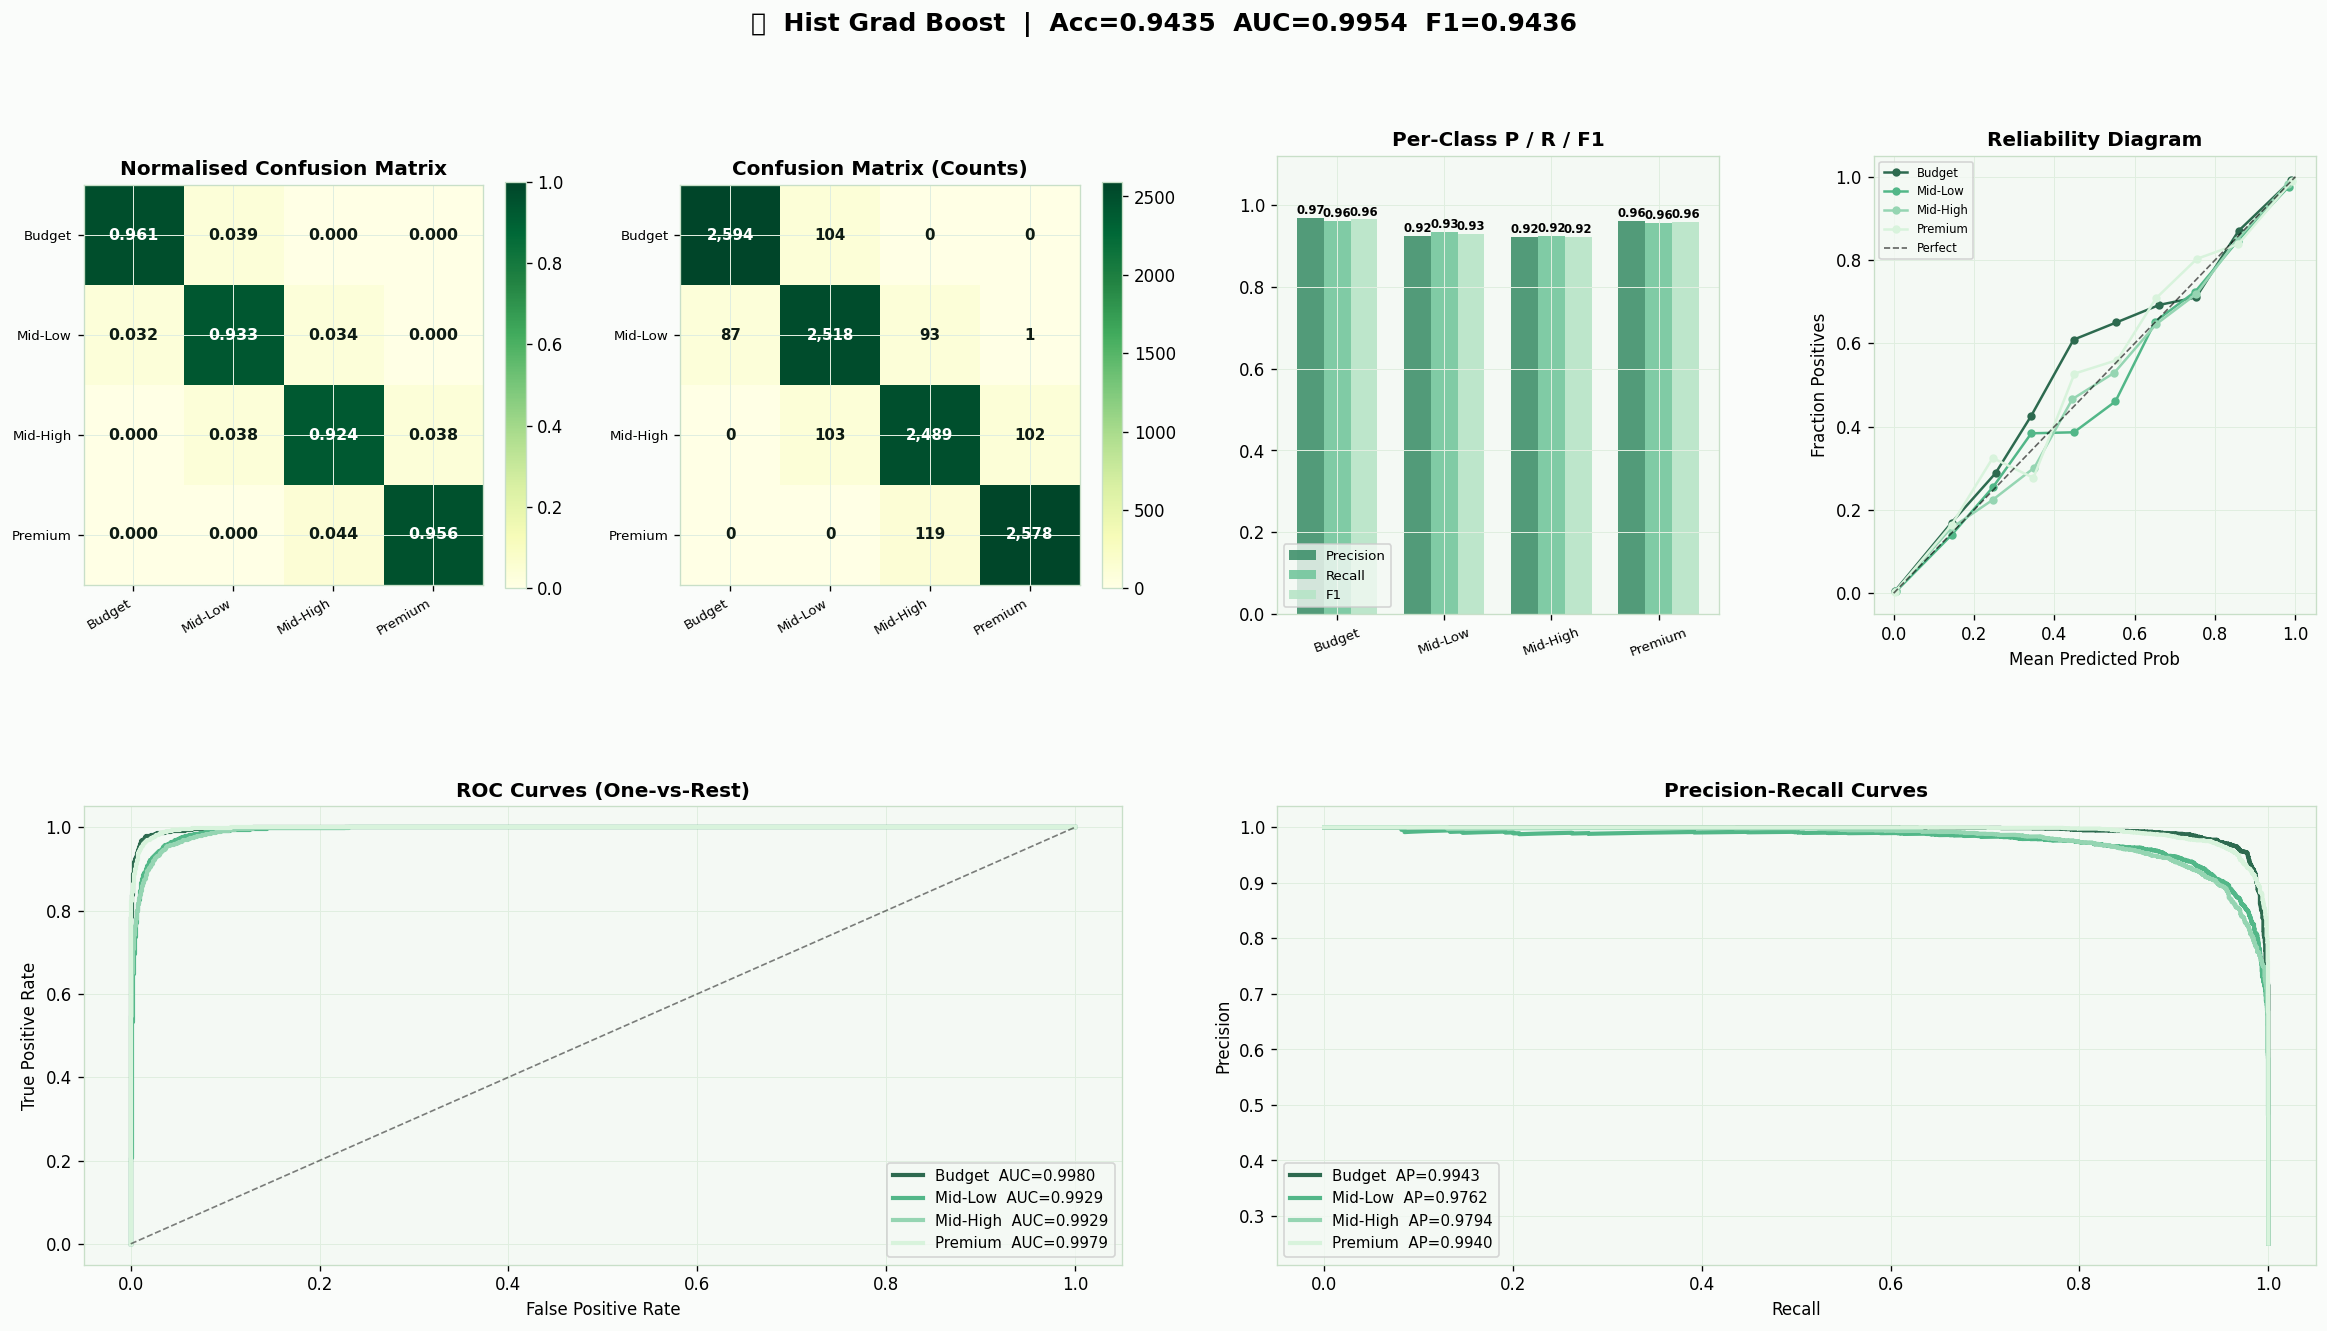

✅ Fig 04 — Best Model Deep Evaluation


In [10]:
yp    = best['y_pred']
yprob = best['y_prob']
ytb   = label_binarize(y_test, classes=[0,1,2,3])

fig = plt.figure(figsize=(24, 12))
fig.patch.set_facecolor('#FAFCFA')
fig.suptitle(f'💎  {best_name}  |  Acc={best["acc"]:.4f}  AUC={best["auc"]:.4f}  F1={best["f1"]:.4f}',
             fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.42, wspace=0.35)

# Normalised CM
ax = fig.add_subplot(gs[0,0])
cm_n = best['cm'].astype(float) / best['cm'].sum(axis=1, keepdims=True)
im = ax.imshow(cm_n, cmap='YlGn', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(TIER_NAMES, rotation=30, ha='right', fontsize=8)
ax.set_yticklabels(TIER_NAMES, fontsize=8)
ax.set_title('Normalised Confusion Matrix', fontweight='bold')
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{cm_n[i,j]:.3f}', ha='center', va='center', fontsize=9.5,
                color='white' if cm_n[i,j]>0.65 else DARK, fontweight='bold')

# Raw count CM
ax2 = fig.add_subplot(gs[0,1])
im2 = ax2.imshow(best['cm'], cmap='YlGn')
plt.colorbar(im2, ax=ax2, fraction=0.046)
ax2.set_xticks(range(4)); ax2.set_yticks(range(4))
ax2.set_xticklabels(TIER_NAMES, rotation=30, ha='right', fontsize=8)
ax2.set_yticklabels(TIER_NAMES, fontsize=8)
ax2.set_title('Confusion Matrix (Counts)', fontweight='bold')
for i in range(4):
    for j in range(4):
        ax2.text(j, i, f'{best["cm"][i,j]:,}', ha='center', va='center', fontsize=9,
                 color='white' if best['cm'][i,j]>best['cm'].max()*0.6 else DARK, fontweight='bold')

# Per-class P/R/F1
ax3 = fig.add_subplot(gs[0,2])
rep  = best['report']
prec = [rep[t]['precision'] for t in TIER_NAMES]
rec  = [rep[t]['recall']    for t in TIER_NAMES]
f1c  = [rep[t]['f1-score']  for t in TIER_NAMES]
ww   = 0.25; x4 = np.arange(4)
ax3.bar(x4-ww, prec, ww, label='Precision', color=GRN[3], alpha=0.9)
ax3.bar(x4,    rec,  ww, label='Recall',    color=GRN[5], alpha=0.9)
ax3.bar(x4+ww, f1c,  ww, label='F1',        color=GRN[7], alpha=0.9)
ax3.set_xticks(x4); ax3.set_xticklabels(TIER_NAMES, rotation=20, fontsize=8)
ax3.set_ylim(0, 1.12); ax3.set_title('Per-Class P / R / F1', fontweight='bold'); ax3.legend(fontsize=8)
for i,(p,r,f) in enumerate(zip(prec,rec,f1c)):
    for xi,v in zip([i-ww,i,i+ww],[p,r,f]):
        ax3.text(xi, v+0.01, f'{v:.2f}', ha='center', fontsize=7, fontweight='bold')

# Calibration
ax4 = fig.add_subplot(gs[0,3])
for i,(tier,color) in enumerate(zip(TIER_NAMES, TIER_COLORS)):
    pt_, pp_ = calibration_curve((y_test==i).astype(int), yprob[:,i], n_bins=10)
    ax4.plot(pp_, pt_, 'o-', color=color, lw=1.5, ms=4, label=tier)
ax4.plot([0,1],[0,1],'k--',lw=1,alpha=0.6,label='Perfect')
ax4.set_title('Reliability Diagram', fontweight='bold')
ax4.set_xlabel('Mean Predicted Prob'); ax4.set_ylabel('Fraction Positives'); ax4.legend(fontsize=7)

# ROC
ax5 = fig.add_subplot(gs[1,0:2])
for i,(tier,color) in enumerate(zip(TIER_NAMES,TIER_COLORS)):
    fpr,tpr,_ = roc_curve(ytb[:,i], yprob[:,i])
    auc_i = roc_auc_score(ytb[:,i], yprob[:,i])
    ax5.plot(fpr, tpr, color=color, lw=2.5, label=f'{tier}  AUC={auc_i:.4f}')
ax5.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
ax5.set_title('ROC Curves (One-vs-Rest)', fontweight='bold')
ax5.set_xlabel('False Positive Rate'); ax5.set_ylabel('True Positive Rate'); ax5.legend(loc='lower right', fontsize=9)

# PR curves
ax6 = fig.add_subplot(gs[1,2:4])
for i,(tier,color) in enumerate(zip(TIER_NAMES,TIER_COLORS)):
    prc_,rcc_,_ = precision_recall_curve(ytb[:,i], yprob[:,i])
    ap = average_precision_score(ytb[:,i], yprob[:,i])
    ax6.plot(rcc_, prc_, color=color, lw=2.5, label=f'{tier}  AP={ap:.4f}')
ax6.set_title('Precision-Recall Curves', fontweight='bold')
ax6.set_xlabel('Recall'); ax6.set_ylabel('Precision'); ax6.legend(loc='lower left', fontsize=9)

plt.savefig('outputs/fig04_best_model_eval.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Fig 04 — Best Model Deep Evaluation")


## 📋 8 — Classification Report

In [11]:
print("=" * 65)
print(f"  CLASSIFICATION REPORT — {best_name}")
print("=" * 65)
print(classification_report(y_test, best['y_pred'], target_names=TIER_NAMES))
print(f"  Test Accuracy : {best['acc']:.4f}  ({best['acc']*100:.2f}%)")
print(f"  Weighted F1   : {best['f1']:.4f}")
print(f"  ROC-AUC (OvR) : {best['auc']:.4f}")
print(f"  Log-Loss      : {best['ll']:.4f}")
print("=" * 65)


  CLASSIFICATION REPORT — Hist Grad Boost
              precision    recall  f1-score   support

      Budget       0.97      0.96      0.96      2698
     Mid-Low       0.92      0.93      0.93      2699
    Mid-High       0.92      0.92      0.92      2694
     Premium       0.96      0.96      0.96      2697

    accuracy                           0.94     10788
   macro avg       0.94      0.94      0.94     10788
weighted avg       0.94      0.94      0.94     10788

  Test Accuracy : 0.9435  (94.35%)
  Weighted F1   : 0.9436
  ROC-AUC (OvR) : 0.9954
  Log-Loss      : 0.1439


## 🔬 9 — Feature Importance (MDI + Permutation)

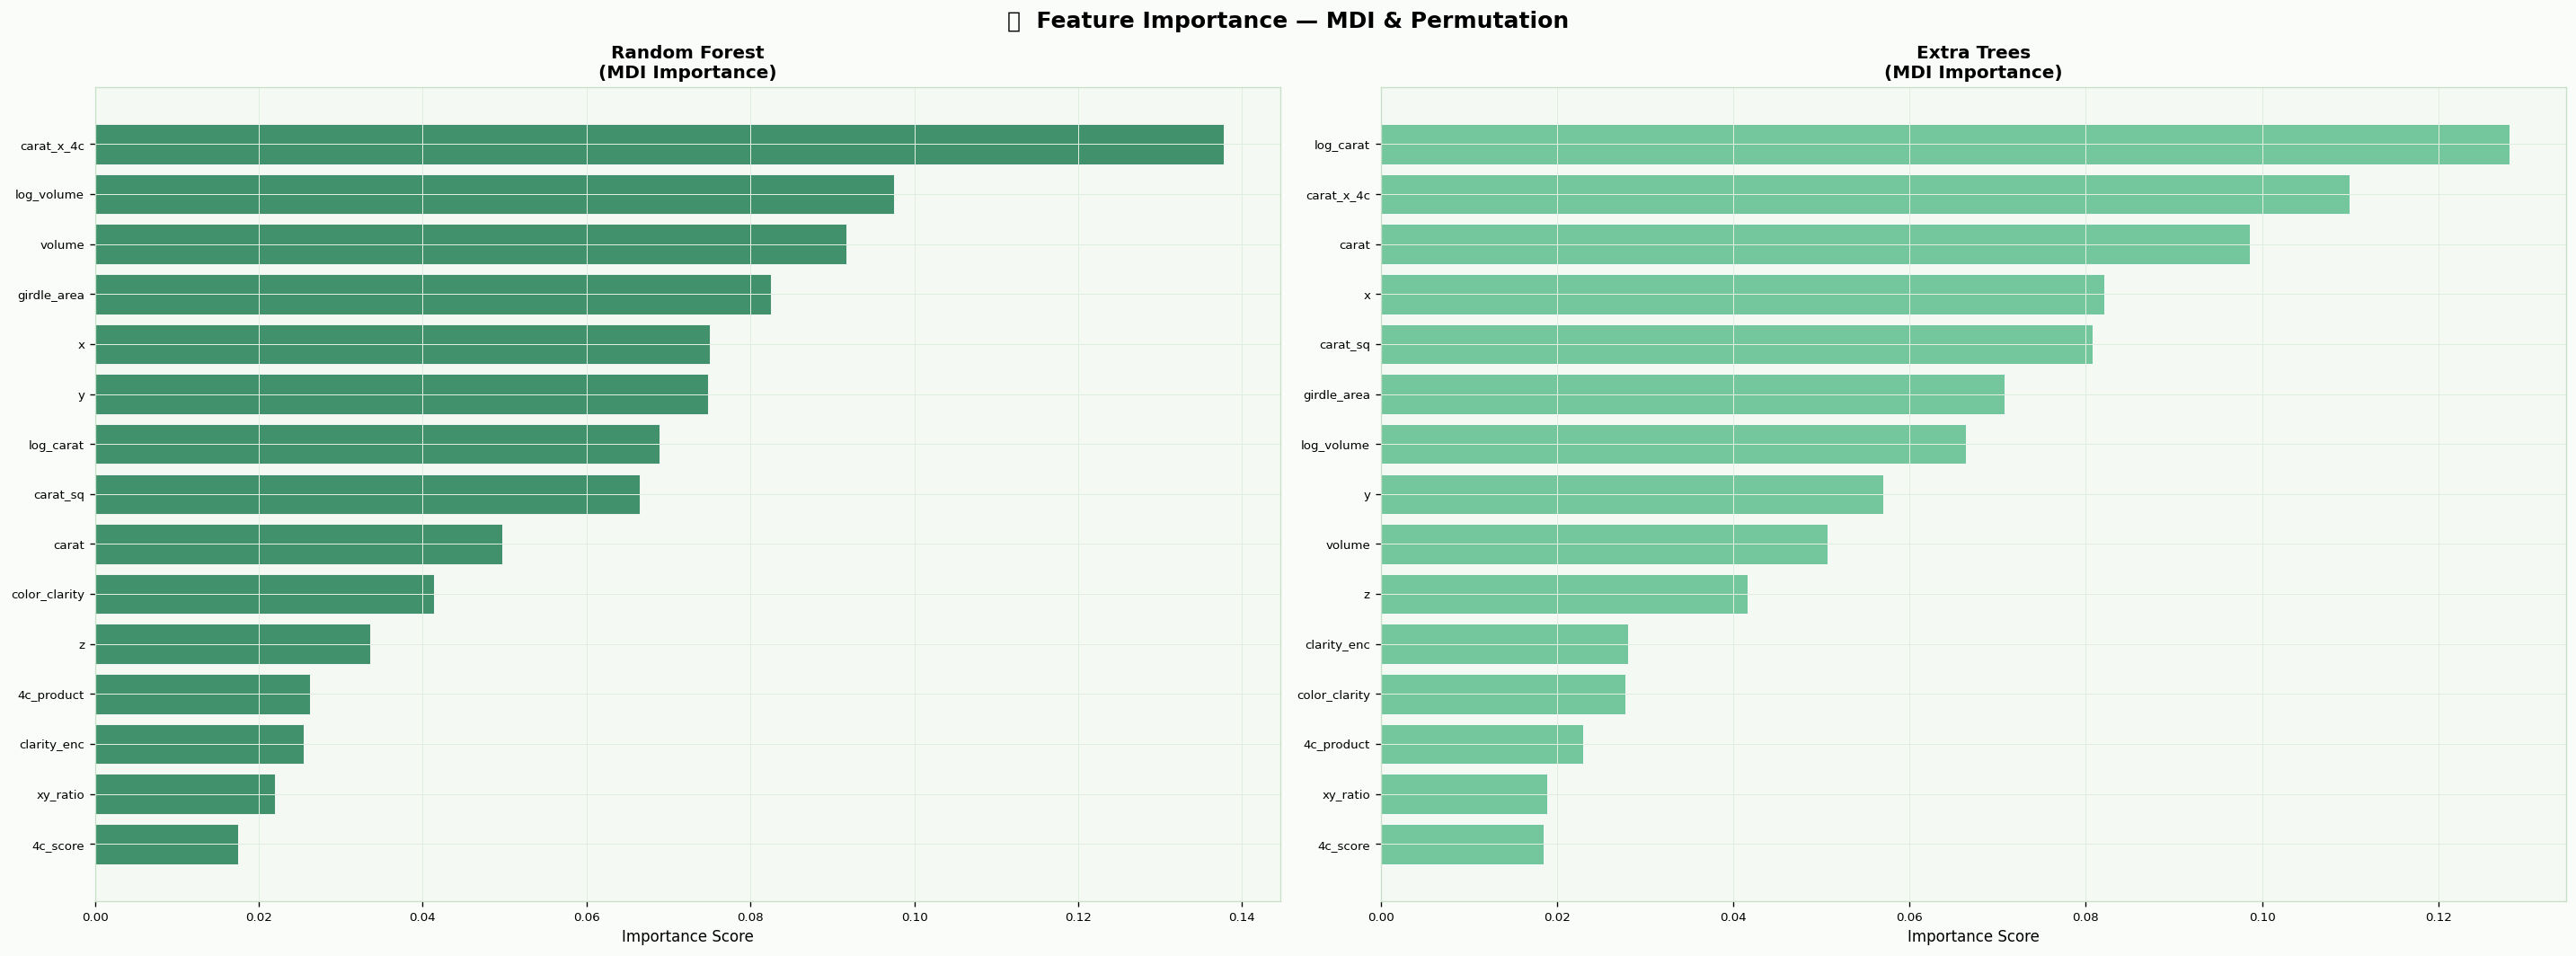


Computing permutation importance (n=2000 samples)...


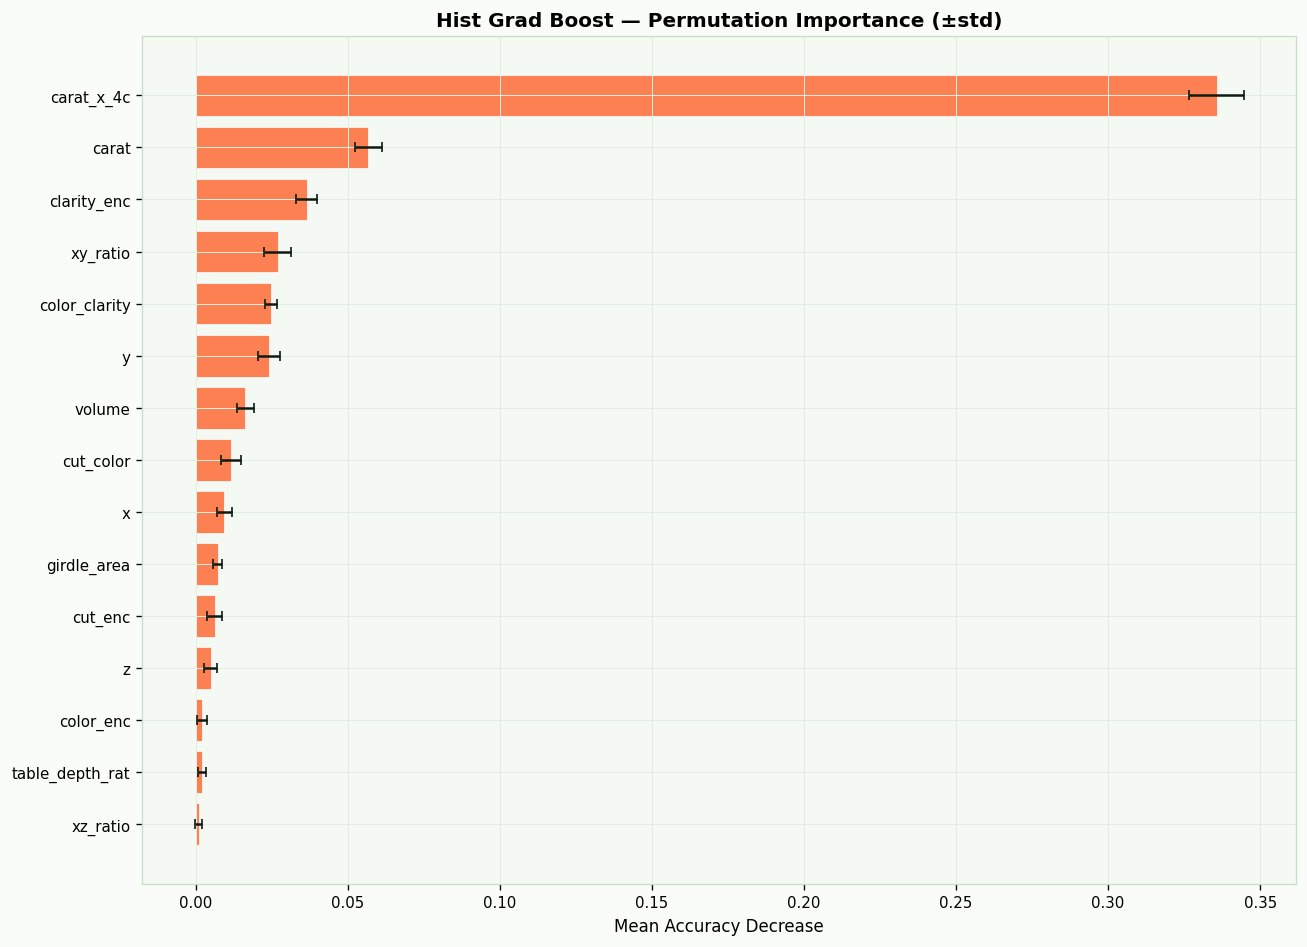

✅ Fig 05-06 — Feature Importance


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(24, 9))
fig.patch.set_facecolor('#FAFCFA')
fig.suptitle('💎  Feature Importance — MDI & Permutation', fontsize=15, fontweight='bold')

for ax, name, color in zip(axes, ['Random Forest','Extra Trees'],
                                   [GRN[3], GRN[5]]):
    m   = results[name]['model']
    imp = m.feature_importances_
    idx = np.argsort(imp)[::-1][:15]
    ax.barh([FEATURE_COLS[i] for i in idx][::-1], imp[idx][::-1],
             color=color, edgecolor='white', lw=0.5)
    ax.set_title(f'{name}\n(MDI Importance)', fontweight='bold')
    ax.set_xlabel('Importance Score'); ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('outputs/fig05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Permutation importance on best model
print("\nComputing permutation importance (n=2000 samples)...")
pidx = np.random.RandomState(42).choice(len(X_test), 2000, replace=False)
Xperm = X_test[pidx]
pi = permutation_importance(best['model'], Xperm, y_test[pidx], n_repeats=10, random_state=42, n_jobs=-1)
si  = np.argsort(pi.importances_mean)[::-1][:15]

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor('#FAFCFA')
ax.barh([FEATURE_COLS[i] for i in si][::-1], pi.importances_mean[si][::-1],
         xerr=pi.importances_std[si][::-1],
         color=ACCENT, edgecolor='white', lw=0.5, capsize=3, ecolor=DARK, alpha=0.85)
ax.set_title(f'{best_name} — Permutation Importance (±std)', fontweight='bold')
ax.set_xlabel('Mean Accuracy Decrease'); ax.tick_params(labelsize=9)
plt.tight_layout()
plt.savefig('outputs/fig06_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Fig 05-06 — Feature Importance")

## 🌐 10 — PCA 2D Projection

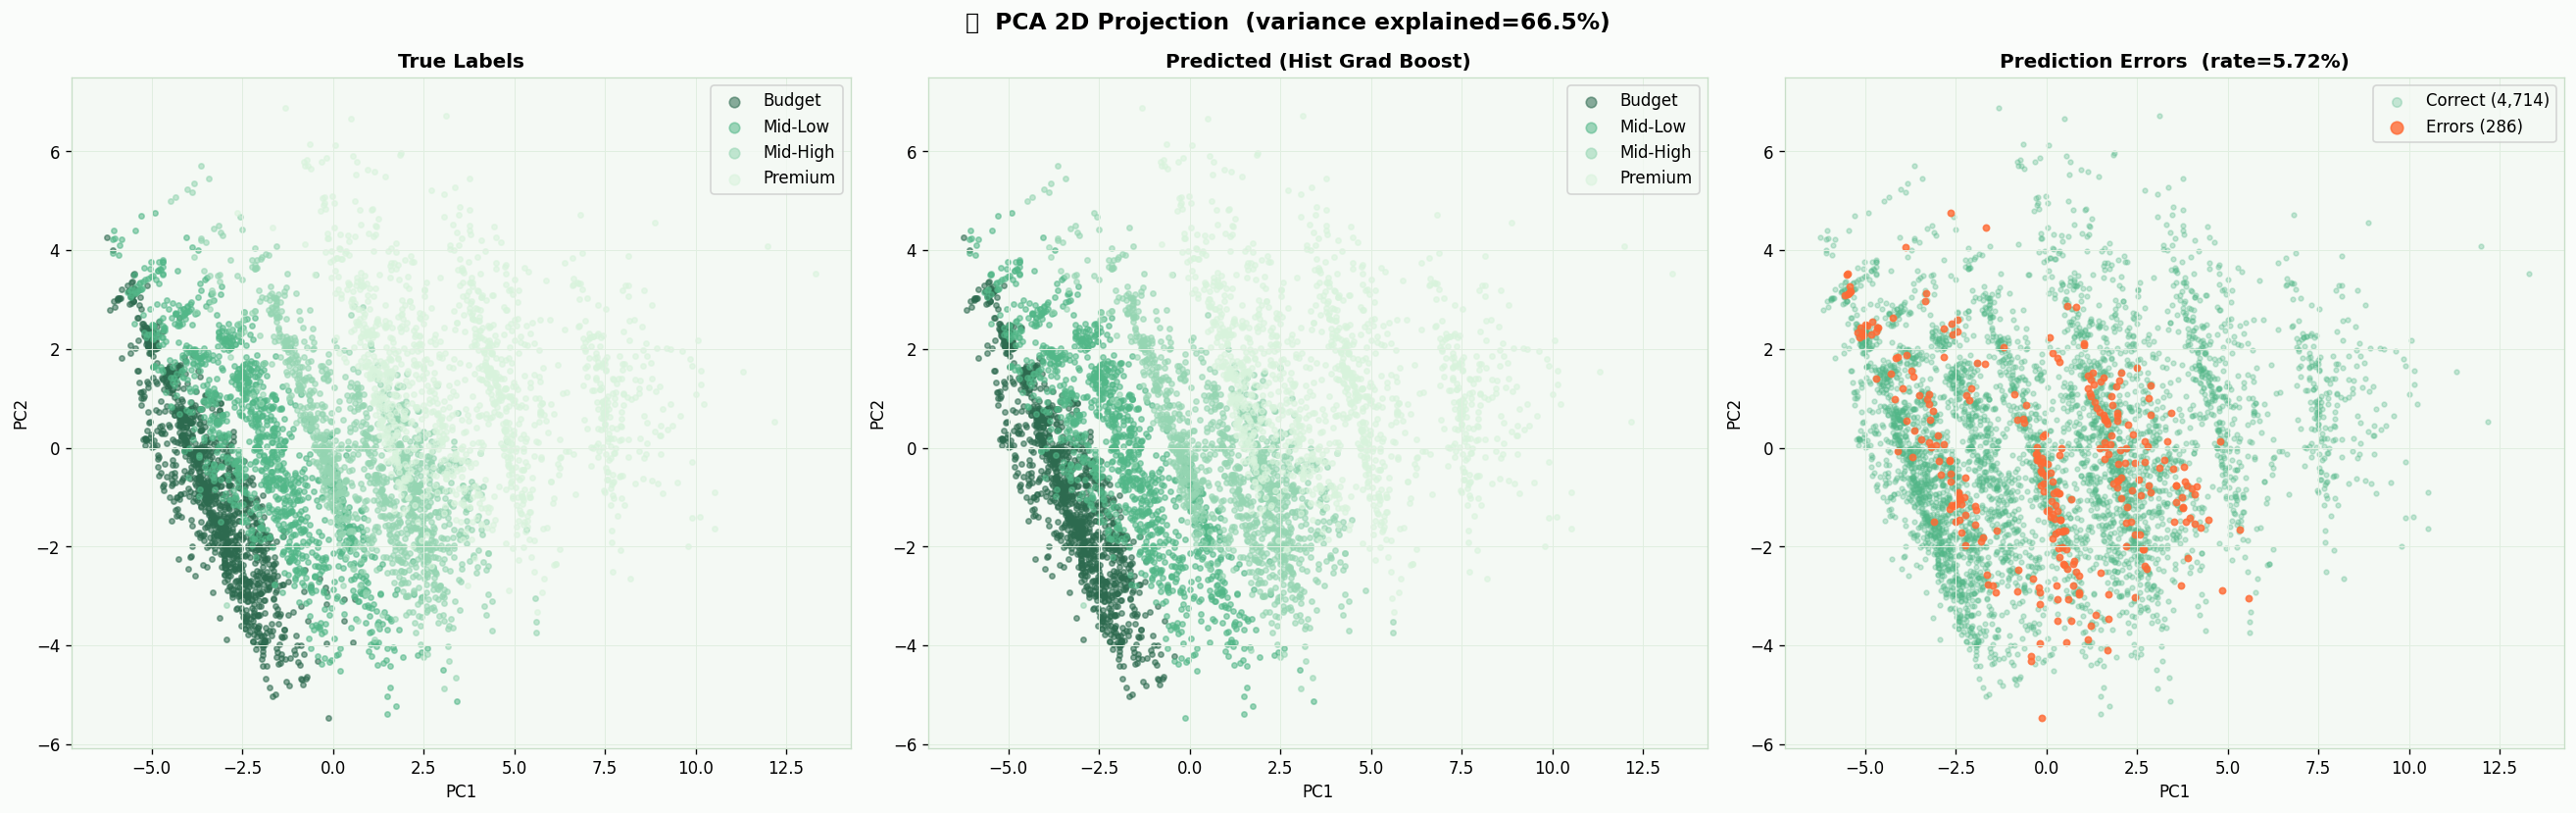

✅ Fig 07 — PCA Projection


In [14]:
pca   = PCA(n_components=2, random_state=42)
Xpca  = pca.fit_transform(scaler.transform(X_test[:5000]))
yt5   = y_test[:5000]
yp5   = best['y_pred'][:5000]
correct = (yt5 == yp5)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.patch.set_facecolor('#FAFCFA')
fig.suptitle(f'💎  PCA 2D Projection  (variance explained={pca.explained_variance_ratio_.sum():.1%})',
             fontsize=14, fontweight='bold')

for i,(t,c) in enumerate(zip(TIER_NAMES, TIER_COLORS)):
    mask = yt5 == i
    axes[0].scatter(Xpca[mask,0], Xpca[mask,1], c=c, s=10, alpha=0.55, label=t)
axes[0].set_title('True Labels', fontweight='bold'); axes[0].legend(markerscale=2)

for i,(t,c) in enumerate(zip(TIER_NAMES, TIER_COLORS)):
    mask = yp5 == i
    axes[1].scatter(Xpca[mask,0], Xpca[mask,1], c=c, s=10, alpha=0.55, label=t)
axes[1].set_title(f'Predicted ({best_name})', fontweight='bold'); axes[1].legend(markerscale=2)

axes[2].scatter(Xpca[correct,0],  Xpca[correct,1],  c=GRN[4], s=8,  alpha=0.3,  label=f'Correct ({correct.sum():,})')
axes[2].scatter(Xpca[~correct,0], Xpca[~correct,1], c=ACCENT, s=14, alpha=0.8,  label=f'Errors ({(~correct).sum():,})')
axes[2].set_title(f'Prediction Errors  (rate={1-correct.mean():.2%})', fontweight='bold')
axes[2].legend(markerscale=2)

for ax in axes: ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout()
plt.savefig('outputs/fig07_pca_projection.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Fig 07 — PCA Projection")


## 🧠 11 — Kernel SHAP (Implemented from Scratch)

In [15]:
# ─────────────────────────────────────────────────────────────────────────
# KERNEL SHAP — Model-agnostic Shapley value estimation
# Reference: Lundberg & Lee (2017) "A Unified Approach to Interpreting
#            Model Predictions"  https://arxiv.org/abs/1705.07874
#
# Algorithm:
#   1. Sample random binary coalitions z ∈ {0,1}^n
#   2. For each coalition, create perturbed input (keep masked features,
#      replace others with background mean)
#   3. Get model predictions for all perturbed inputs
#   4. Weight coalitions by Shapley kernel:
#        w(z) = (n-1) / [C(n,|z|) × |z| × (n-|z|)]
#   5. Solve weighted linear regression: φ = argmin Σ w(z)(f(z)-g(z))²
#      where g is the linear surrogate with Shapley value coefficients
# ─────────────────────────────────────────────────────────────────────────

def kernel_shap(model, x_instance, X_background, n_samples=64, random_state=42):
    rng = np.random.RandomState(random_state)
    n   = len(FEATURE_COLS)
    bg  = X_background[rng.choice(len(X_background), min(50, len(X_background)), replace=False)]
    baseline = model.predict_proba(bg).mean(axis=0)

    masks   = np.zeros((n_samples, n), dtype=float)
    preds   = np.zeros((n_samples, 4))
    weights = np.zeros(n_samples)

    for i in range(n_samples):
        k       = rng.randint(1, n)
        indices = rng.choice(n, k, replace=False)
        mask    = np.zeros(n); mask[indices] = 1.0
        masks[i]= mask
        x_pert  = np.where(mask == 1, x_instance, bg.mean(axis=0))
        preds[i]= model.predict_proba(x_pert.reshape(1,-1))[0]
        z = int(mask.sum())
        weights[i] = 1e6 if z in (0, n) else (n-1) / (comb(n,z) * z * (n-z) + 1e-10)

    shap_vals = np.zeros((4, n))
    for cls in range(4):
        reg = Ridge(alpha=0.01, fit_intercept=True)
        reg.fit(masks, preds[:,cls] - baseline[cls], sample_weight=weights)
        shap_vals[cls] = reg.coef_
    return shap_vals, baseline

# ── Compute SHAP for 20 test instances (5 per class) ─────────────────────
shap_idx = []
for cls in range(4):
    cidx = np.where(y_test == cls)[0]
    shap_idx.extend(np.random.RandomState(cls).choice(cidx, 5, replace=False).tolist())
shap_idx   = np.array(shap_idx)
X_shap     = X_test[shap_idx]
y_shap     = y_test[shap_idx]
n_features = len(FEATURE_COLS)
shap_matrix = np.zeros((20, 4, n_features))

print(f"Computing Kernel SHAP for {len(shap_idx)} instances (64 coalitions each)...")
for i, xi in enumerate(X_shap):
    sv, _ = kernel_shap(best['model'], xi, X_train, n_samples=64, random_state=i)
    shap_matrix[i] = sv

global_imp    = np.abs(shap_matrix).mean(axis=0).mean(axis=0)
mean_abs_shap = np.abs(shap_matrix).mean(axis=0)
print("✅ Kernel SHAP computed")


Computing Kernel SHAP for 20 instances (64 coalitions each)...
✅ Kernel SHAP computed


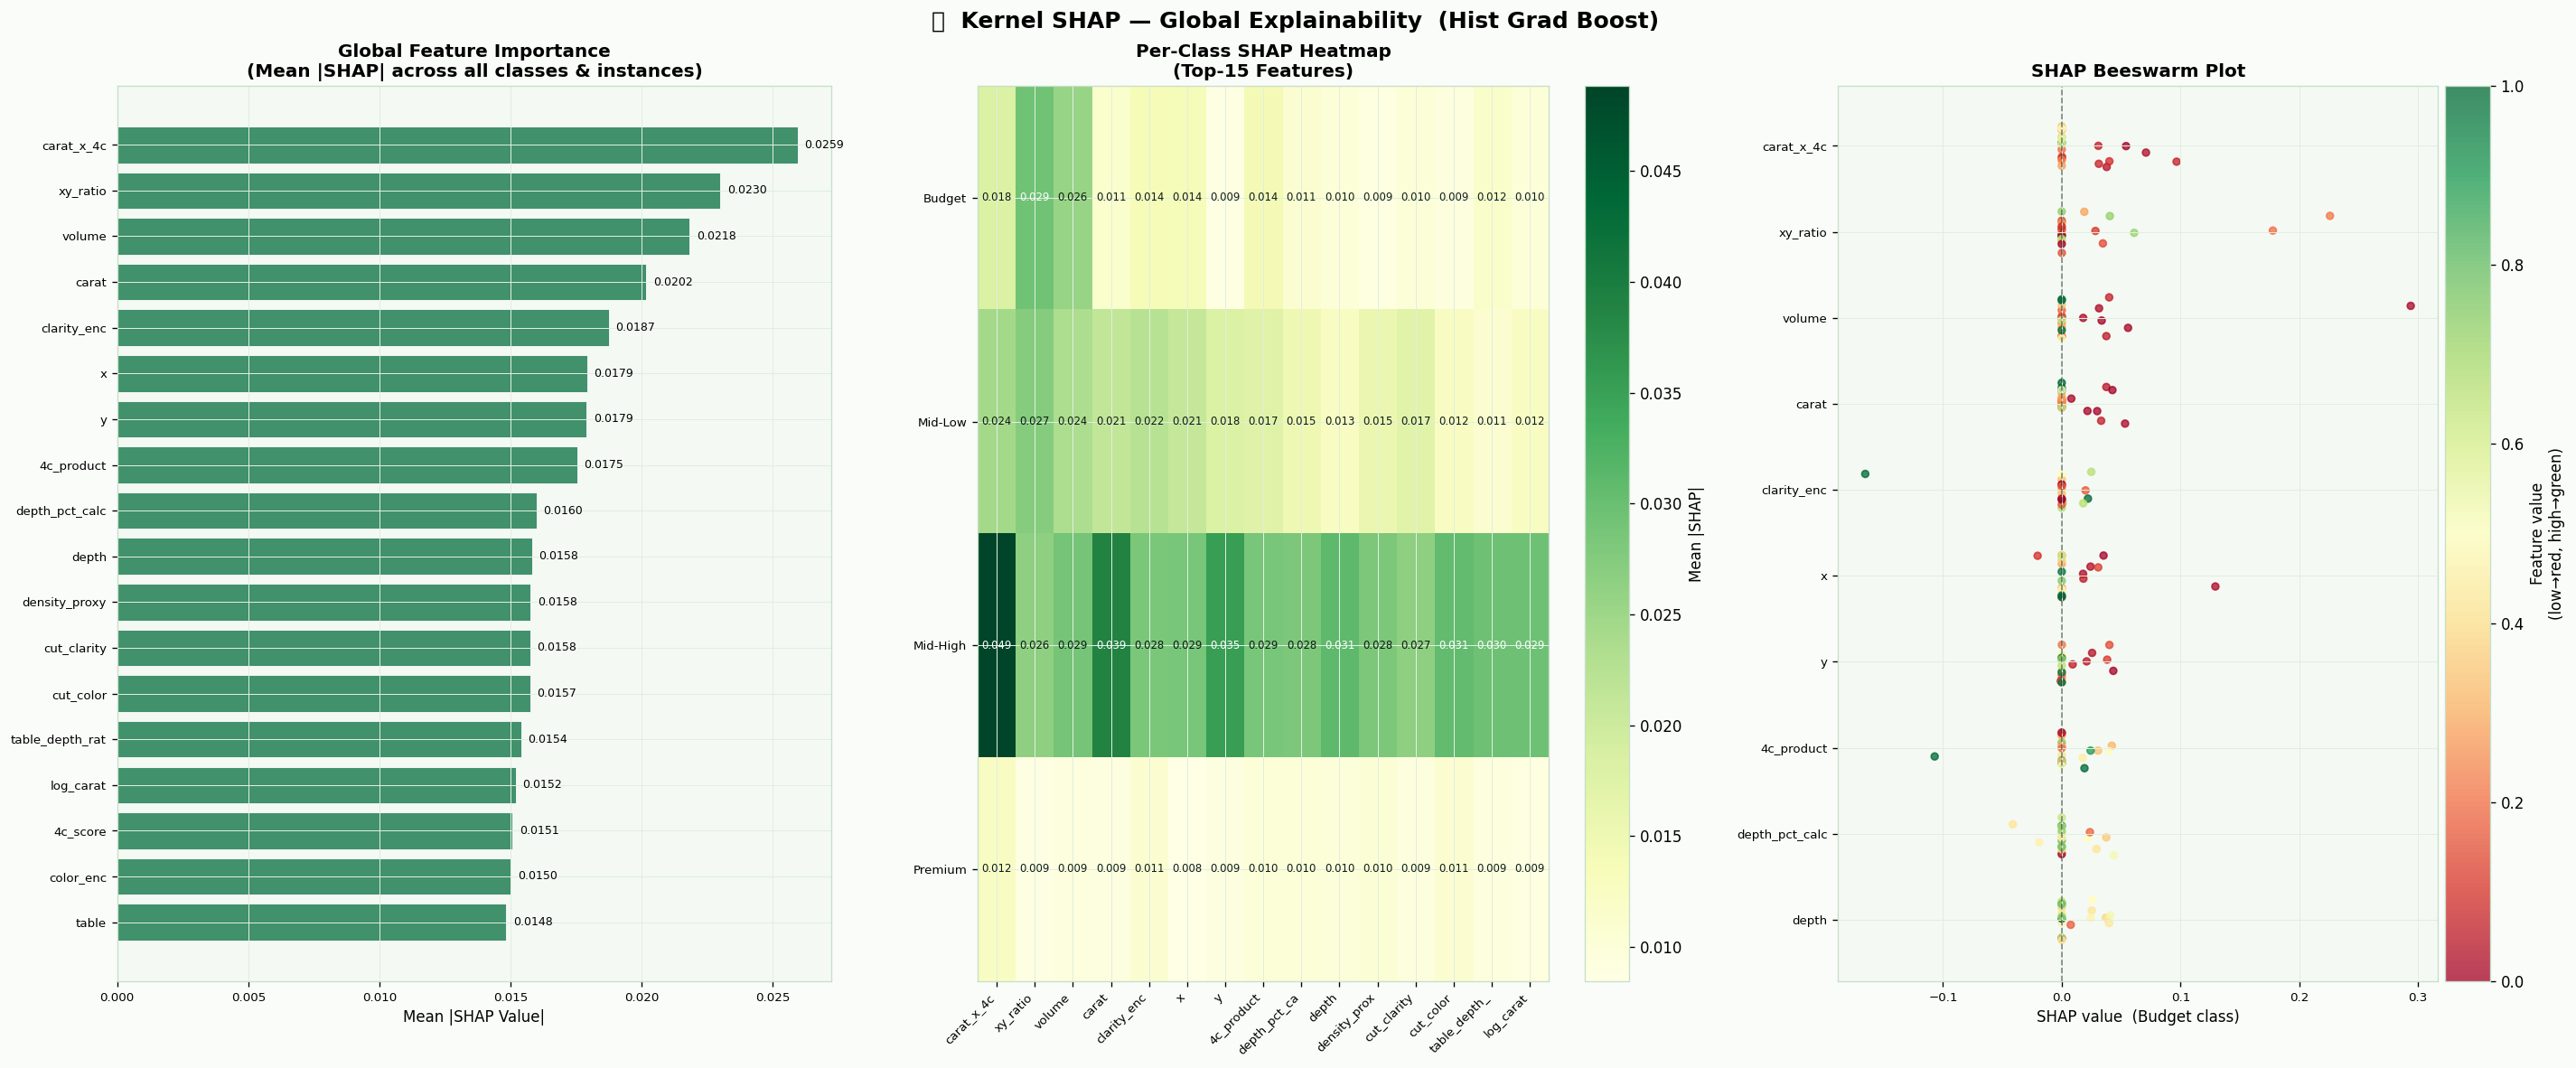

✅ Fig 08 — SHAP Global Summary


In [16]:
# ── SHAP Global Summary Plot ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(24, 10))
fig.patch.set_facecolor('#FAFCFA')
fig.suptitle(f'💎  Kernel SHAP — Global Explainability  ({best_name})',
             fontsize=15, fontweight='bold')

# Global importance bar
idx_g = np.argsort(global_imp)[::-1][:18]
axes[0].barh([FEATURE_COLS[i] for i in idx_g][::-1], global_imp[idx_g][::-1],
              color=GRN[3], edgecolor='white', lw=0.5)
axes[0].set_title('Global Feature Importance\n(Mean |SHAP| across all classes & instances)',
                   fontweight='bold')
axes[0].set_xlabel('Mean |SHAP Value|')
for i, v in enumerate(global_imp[idx_g][::-1]):
    axes[0].text(v + global_imp.max()*0.01, i, f'{v:.4f}', va='center', fontsize=7.5)

# Per-class heatmap
top15    = np.argsort(global_imp)[::-1][:15]
heat_data = mean_abs_shap[:, top15]
im = axes[1].imshow(heat_data, cmap='YlGn', aspect='auto')
plt.colorbar(im, ax=axes[1], label='Mean |SHAP|')
axes[1].set_xticks(range(15))
axes[1].set_xticklabels([FEATURE_COLS[i][:12] for i in top15], rotation=45, ha='right', fontsize=8)
axes[1].set_yticks(range(4)); axes[1].set_yticklabels(TIER_NAMES, fontsize=9)
axes[1].set_title('Per-Class SHAP Heatmap\n(Top-15 Features)', fontweight='bold')
for i in range(4):
    for j in range(15):
        axes[1].text(j, i, f'{heat_data[i,j]:.3f}', ha='center', va='center',
                     fontsize=7, color='white' if heat_data[i,j]>heat_data.max()*0.6 else DARK)

# Beeswarm plot — Budget class
ax = axes[2]
top10 = np.argsort(global_imp)[::-1][:10]
for k, feat_i in enumerate(top10[::-1]):
    fv   = X_shap[:, feat_i]
    sv2  = shap_matrix[:, 0, feat_i]
    fn   = (fv - fv.min()) / (fv.max() - fv.min() + 1e-8)
    jit  = np.random.RandomState(k).uniform(-0.25, 0.25, len(sv2))
    sc   = ax.scatter(sv2, [k + jit[i] for i in range(len(sv2))],
                       c=fn, cmap='RdYlGn', s=22, alpha=0.75, vmin=0, vmax=1)
ax.axvline(0, color=DARK, lw=1, ls='--', alpha=0.5)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels([FEATURE_COLS[i][:16] for i in top10[::-1]], fontsize=8)
ax.set_xlabel('SHAP value  (Budget class)'); ax.set_title('SHAP Beeswarm Plot', fontweight='bold')
plt.colorbar(sc, ax=ax, label='Feature value\n(low→red, high→green)', pad=0.01)

for a in axes: a.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig('outputs/fig08_shap_global.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Fig 08 — SHAP Global Summary")


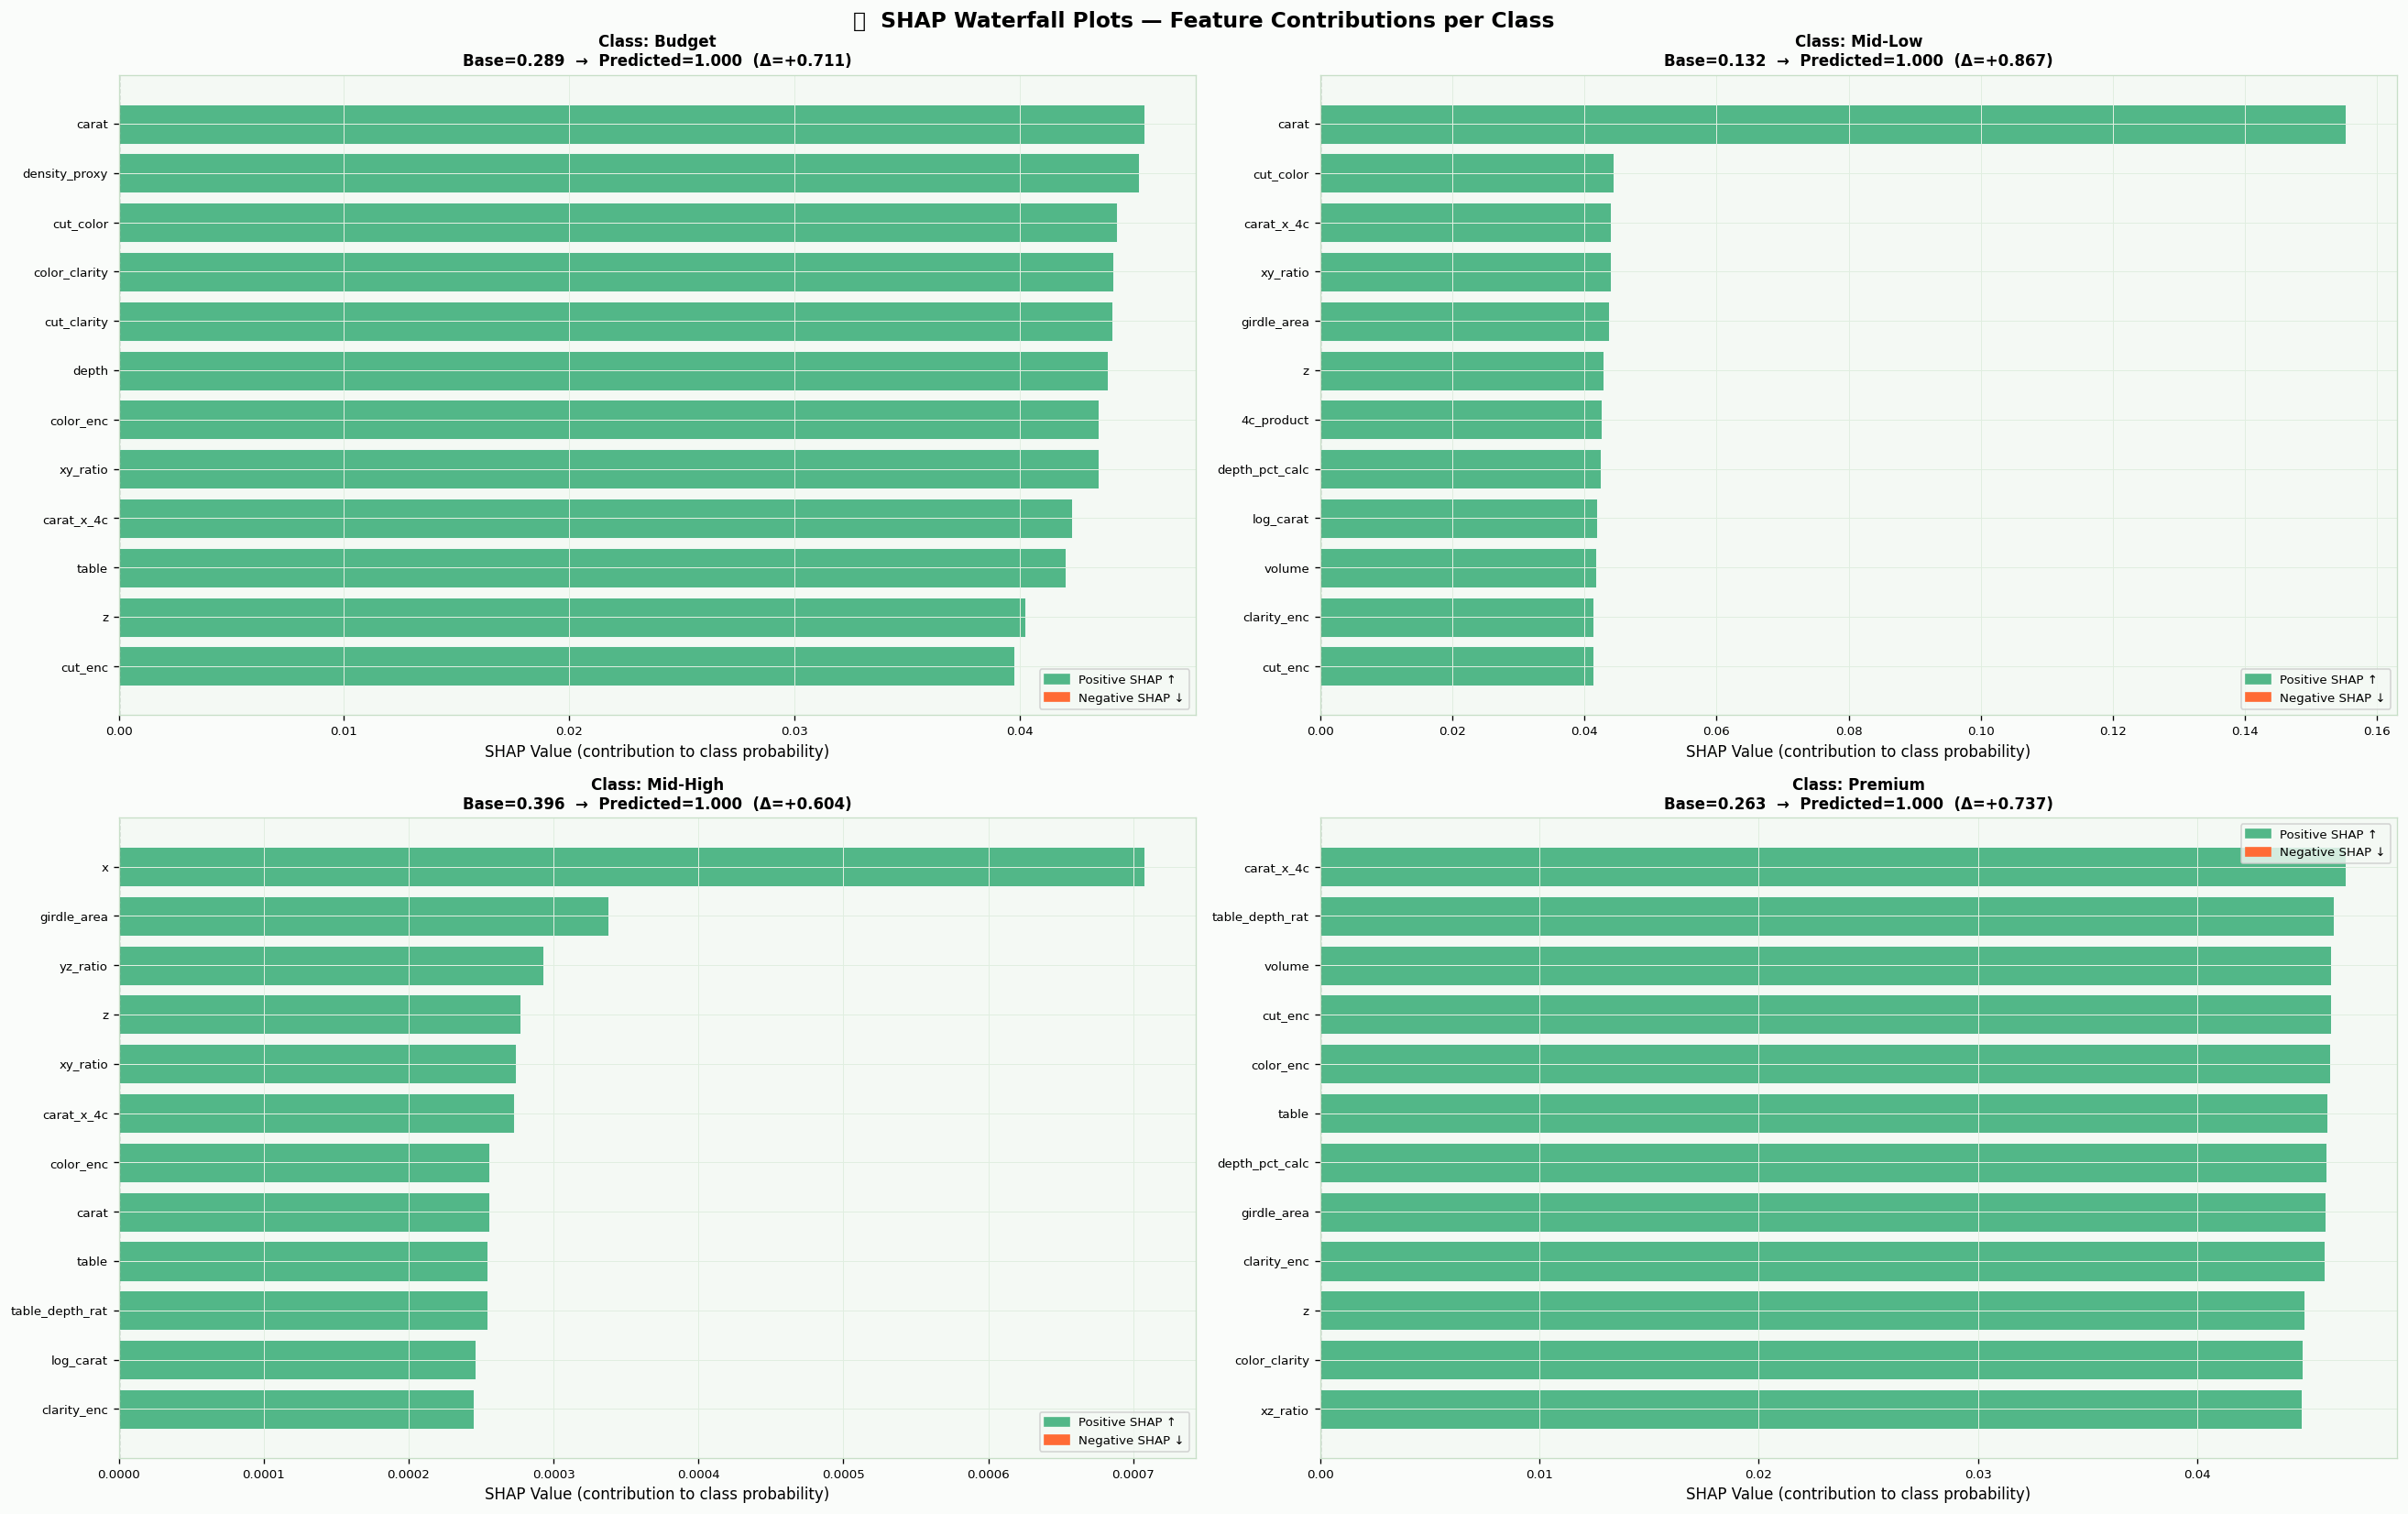

✅ Fig 09 — SHAP Waterfall


In [17]:
# ── SHAP Waterfall (per class, single instance each) ─────────────────────
fig, axes = plt.subplots(2, 2, figsize=(22, 14))
fig.patch.set_facecolor('#FAFCFA')
fig.suptitle('💎  SHAP Waterfall Plots — Feature Contributions per Class',
             fontsize=14, fontweight='bold')

# Pick one representative instance per class
lime_instances = []
for cls in range(4):
    cidx = np.where(y_test == cls)[0]
    best_i = cidx[np.argmax(best['y_prob'][cidx, cls])]
    lime_instances.append(X_test[best_i])

for ax, (cls, xi) in zip(axes.flat, enumerate(lime_instances)):
    sv, base = kernel_shap(best['model'], xi, X_train, n_samples=80, random_state=cls+50)
    sv_cls   = sv[cls]
    pred_prob = best['model'].predict_proba(xi.reshape(1,-1))[0][cls]
    top12 = np.argsort(np.abs(sv_cls))[::-1][:12]
    vals  = sv_cls[top12]; names = [FEATURE_COLS[i][:22] for i in top12]
    so    = np.argsort(vals); vals = vals[so]; names = [names[i] for i in so]
    ax.barh(names, vals, color=[GRN[4] if v>0 else ACCENT for v in vals],
             edgecolor='white', lw=0.5)
    ax.axvline(0, color=DARK, lw=0.8, ls='--', alpha=0.6)
    ax.set_title(f'Class: {TIER_NAMES[cls]}\n'
                 f'Base={base[cls]:.3f}  →  Predicted={pred_prob:.3f}  (Δ={pred_prob-base[cls]:+.3f})',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('SHAP Value (contribution to class probability)')
    ax.tick_params(labelsize=8)
    ax.legend(handles=[mpatches.Patch(color=GRN[4], label='Positive SHAP ↑'),
                        mpatches.Patch(color=ACCENT, label='Negative SHAP ↓')], fontsize=8)

plt.tight_layout()
plt.savefig('outputs/fig09_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Fig 09 — SHAP Waterfall")


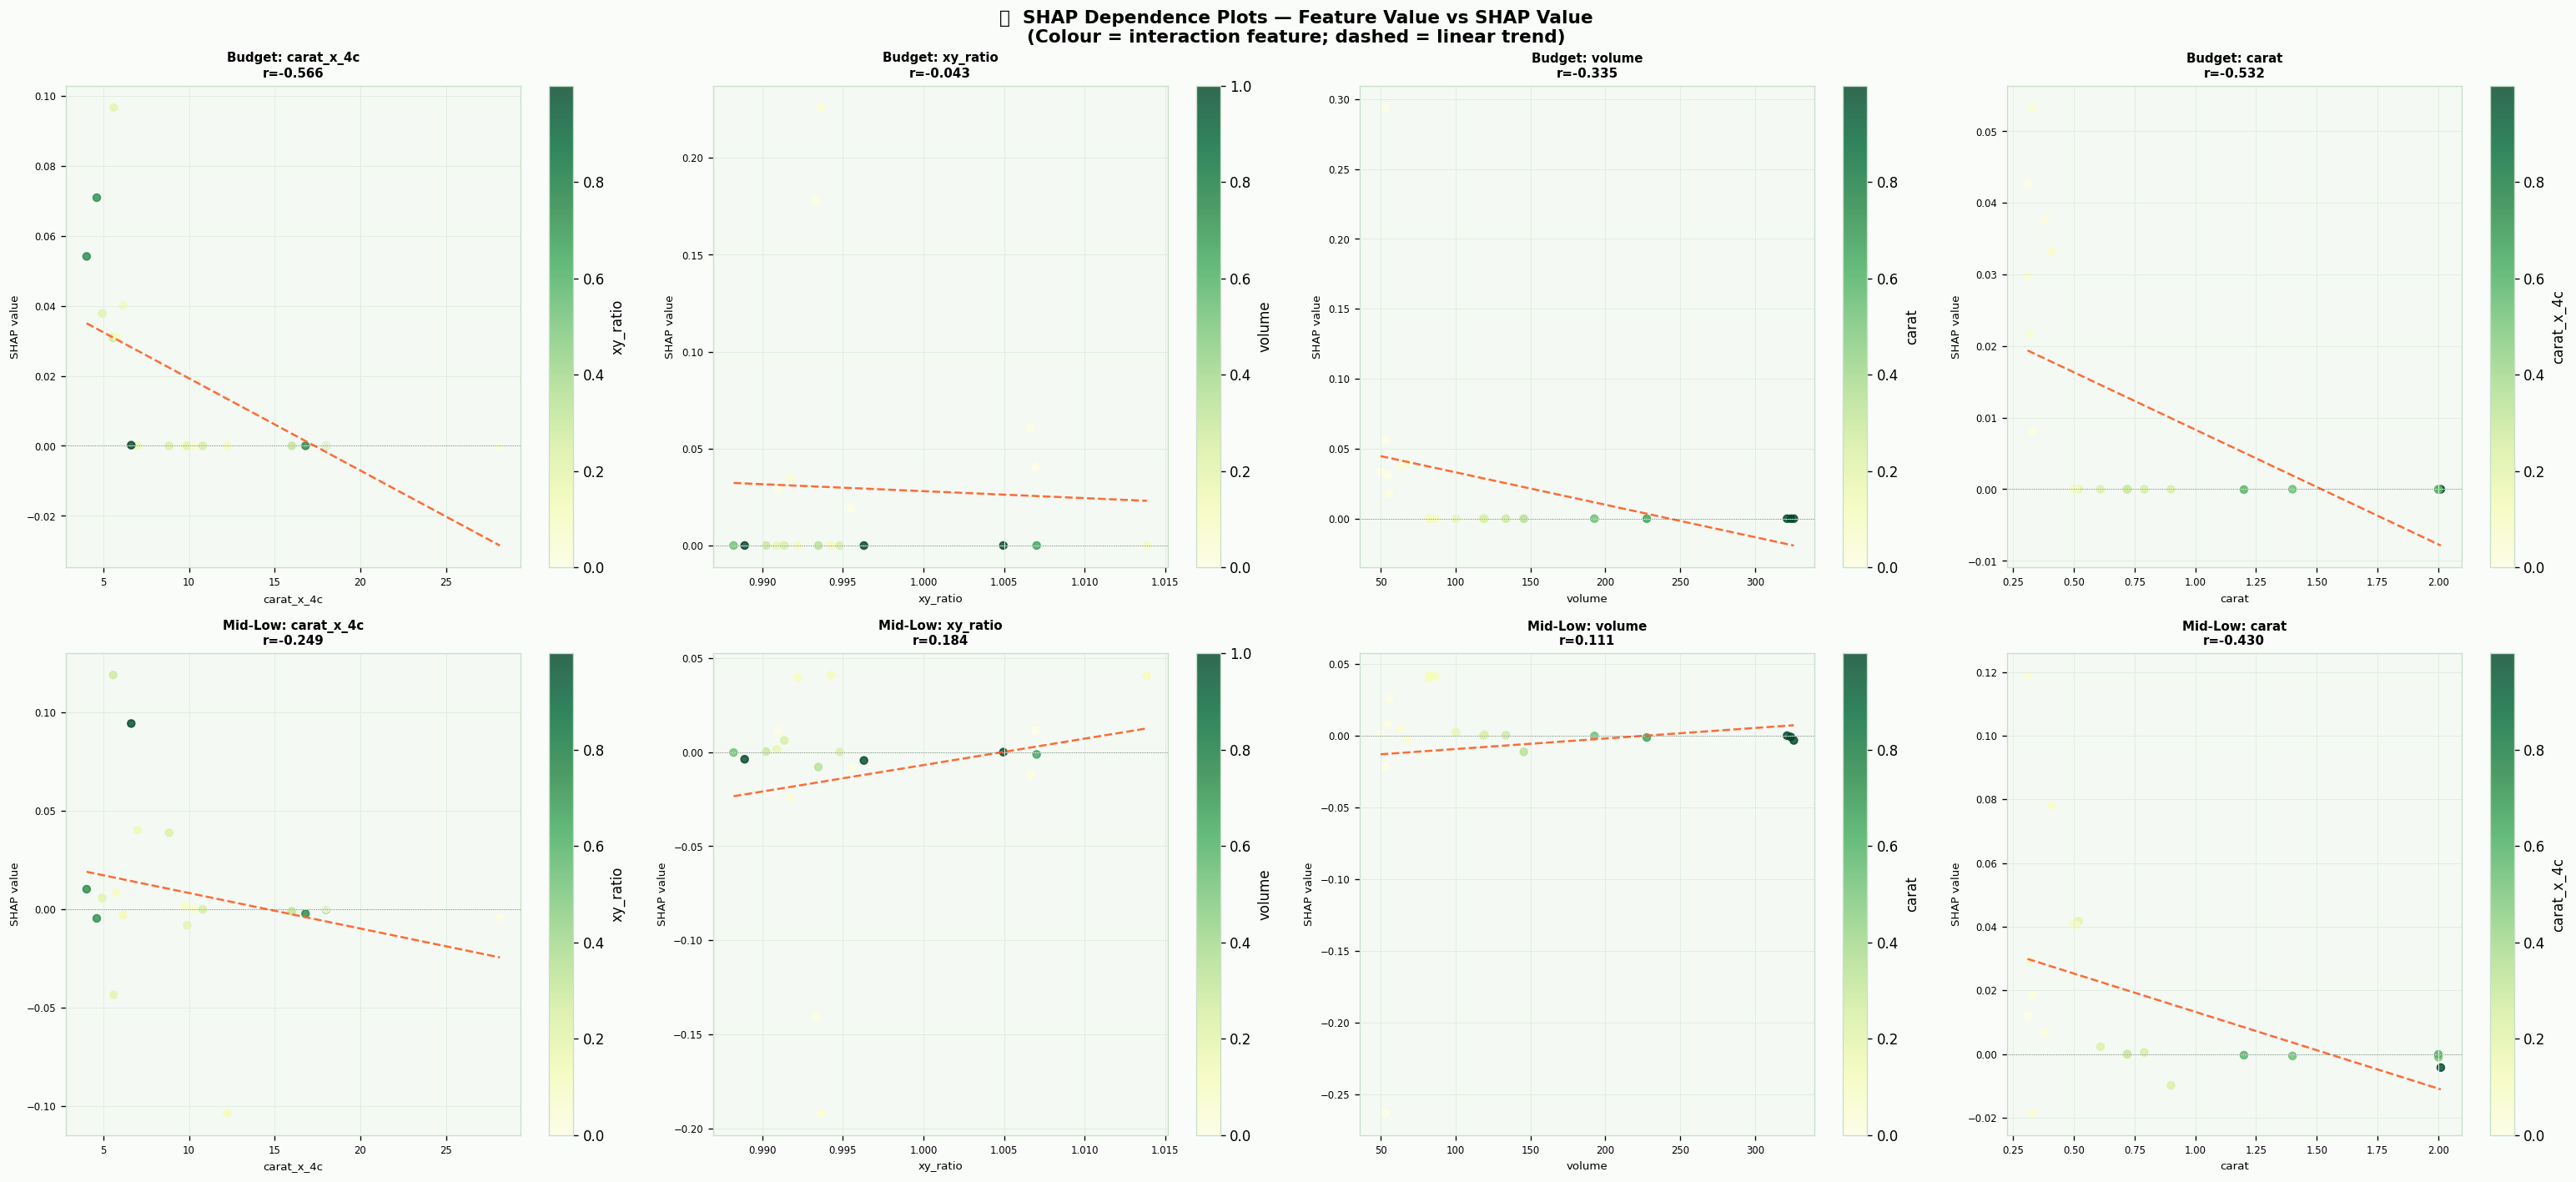

✅ Fig 10 — SHAP Dependence


In [18]:
# ── SHAP Dependence Plots ────────────────────────────────────────────────
top4 = np.argsort(global_imp)[::-1][:4]
fig, axes = plt.subplots(2, 4, figsize=(26, 12))
fig.patch.set_facecolor('#FAFCFA')
fig.suptitle('💎  SHAP Dependence Plots — Feature Value vs SHAP Value\n'
             '(Colour = interaction feature; dashed = linear trend)',
             fontsize=13, fontweight='bold')

for row, cls in enumerate([0, 1]):
    shap_cls = shap_matrix[:, cls, :]
    for col, feat_i in enumerate(top4):
        ax = axes[row, col]
        fv  = X_shap[:, feat_i]; sv2 = shap_cls[:, feat_i]
        int_i = top4[(col+1) % 4]; iv = X_shap[:, int_i]
        iv_n  = (iv - iv.min()) / (iv.max() - iv.min() + 1e-8)
        sc    = ax.scatter(fv, sv2, c=iv_n, cmap='YlGn', s=28, alpha=0.8)
        slope, intercept, r, *_ = linregress(fv, sv2)
        xl = np.linspace(fv.min(), fv.max(), 100)
        ax.plot(xl, slope*xl+intercept, color=ACCENT, lw=1.5, ls='--')
        ax.axhline(0, color=DARK, lw=0.6, ls=':', alpha=0.5)
        plt.colorbar(sc, ax=ax, label=FEATURE_COLS[int_i][:10])
        ax.set_title(f'{TIER_NAMES[cls]}: {FEATURE_COLS[feat_i][:16]}\nr={r:.3f}',
                     fontweight='bold', fontsize=9)
        ax.set_xlabel(FEATURE_COLS[feat_i][:14], fontsize=8)
        ax.set_ylabel('SHAP value', fontsize=8); ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('outputs/fig10_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Fig 10 — SHAP Dependence")


## 🔍 12 — LIME (Implemented from Scratch)

In [19]:
# ─────────────────────────────────────────────────────────────────────────
# LIME — Local Interpretable Model-Agnostic Explanations
# Reference: Ribeiro, Singh & Guestrin (2016) "'Why Should I Trust You?':
#            Explaining the Predictions of Any Classifier"
#            https://arxiv.org/abs/1602.04938
#
# Algorithm:
#   1. Sample n perturbed versions of instance x by adding Gaussian noise
#   2. Get model predictions on all perturbed samples
#   3. Compute exponential kernel weights: w_i = exp(-d²/2σ²)
#      where d = Euclidean distance to original instance
#   4. Fit weighted Ridge surrogate: g = argmin Σ w_i(f(z_i)-g(z_i))²
#   5. Coefficients of g = local feature importances (LIME values)
# ─────────────────────────────────────────────────────────────────────────

def lime_explain(model, x_instance, X_background, n_samples=250, random_state=42):
    rng      = np.random.RandomState(random_state)
    n        = len(FEATURE_COLS)
    bg_mean  = X_background.mean(0)
    bg_std   = X_background.std(0) + 1e-8
    kw       = np.sqrt(n) * 0.25           # kernel width

    noise    = rng.randn(n_samples, n) * bg_std * 0.5
    Xp       = np.clip(x_instance + noise, X_background.min(0), X_background.max(0))
    Xp[0]    = x_instance                 # always include the original

    probs    = model.predict_proba(Xp)
    dists    = np.sqrt(((Xp - x_instance) ** 2).sum(axis=1))
    weights  = np.exp(-dists**2 / (2 * kw**2))
    Xn       = (Xp - bg_mean) / bg_std    # normalise for interpretable coefficients

    coefs = np.zeros((4, n)); r2s = np.zeros(4)
    for cls in range(4):
        reg = Ridge(alpha=0.1)
        reg.fit(Xn, probs[:, cls], sample_weight=weights)
        coefs[cls] = reg.coef_
        r2s[cls]   = r2_score(probs[:, cls], reg.predict(Xn), sample_weight=weights)
    return coefs, r2s, probs[0]

# ── Compute LIME for 4 instances (one per class — most confident prediction)
print("Computing LIME for 4 representative instances...")
lime_data = []
for cls in range(4):
    cidx   = np.where(y_test == cls)[0]
    best_i = cidx[np.argmax(best['y_prob'][cidx, cls])]
    xi     = X_test[best_i]
    coefs, r2s, pred = lime_explain(best['model'], xi, X_train, n_samples=300, random_state=cls)
    lime_data.append({'cls': cls, 'xi': xi, 'coefs': coefs, 'r2s': r2s, 'pred': pred})
    print(f"  {TIER_NAMES[cls]:10s}  pred_prob={pred[cls]:.3f}  surrogate_R²={r2s[cls]:.3f}")

print("✅ LIME computed")


Computing LIME for 4 representative instances...
  Budget      pred_prob=1.000  surrogate_R²=0.000
  Mid-Low     pred_prob=1.000  surrogate_R²=0.000
  Mid-High    pred_prob=1.000  surrogate_R²=0.000
  Premium     pred_prob=1.000  surrogate_R²=0.000
✅ LIME computed


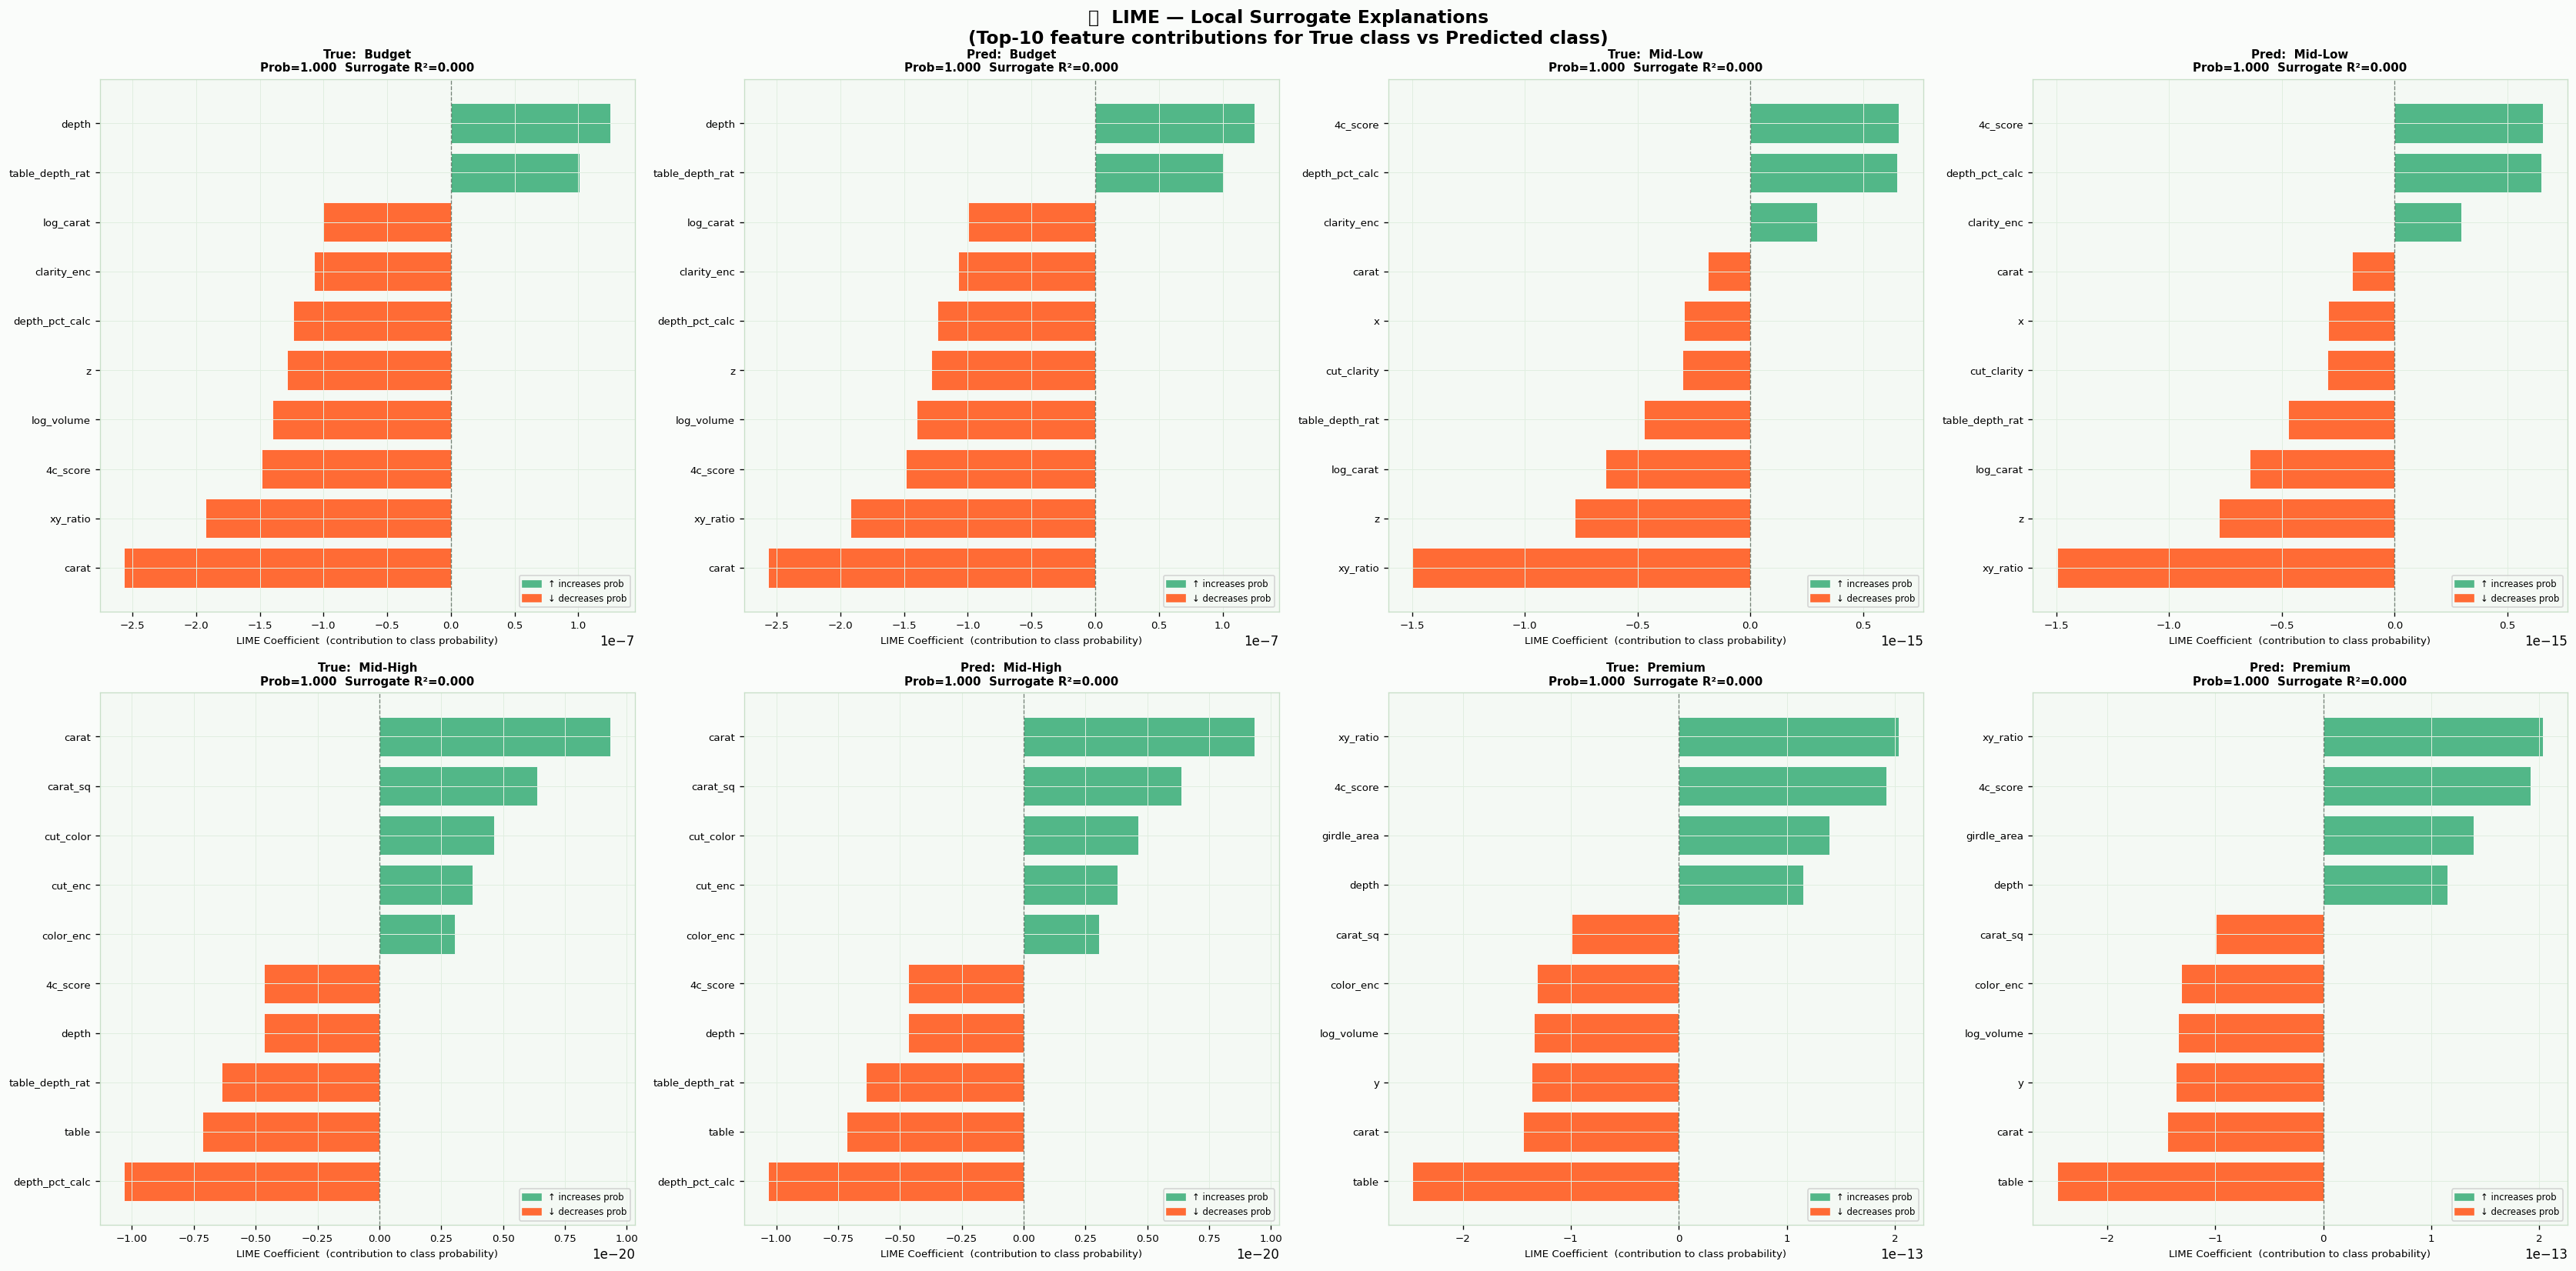

✅ Fig 11 — LIME Explanations


In [20]:
# ── LIME Local Explanation Plots ─────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(28, 14))
fig.patch.set_facecolor('#FAFCFA')
fig.suptitle('💎  LIME — Local Surrogate Explanations\n'
             '(Top-10 feature contributions for True class vs Predicted class)',
             fontsize=14, fontweight='bold')

for row, ld in enumerate(lime_data):
    for col, (c_idx, label) in enumerate([
        (ld['cls'],             f'True:  {TIER_NAMES[ld["cls"]]}'),
        (ld['pred'].argmax(),   f'Pred:  {TIER_NAMES[ld["pred"].argmax()]}'),
    ]):
        ax      = axes[row // 2, row % 2 * 2 + col]
        coef_c  = ld['coefs'][c_idx]
        top10   = np.argsort(np.abs(coef_c))[::-1][:10]
        vals    = coef_c[top10]
        names   = [FEATURE_COLS[i][:20] for i in top10]
        so      = np.argsort(vals); vals = vals[so]; names = [names[i] for i in so]
        colors  = [GRN[4] if v > 0 else ACCENT for v in vals]

        ax.barh(names, vals, color=colors, edgecolor='white', lw=0.5)
        ax.axvline(0, color=DARK, lw=0.8, ls='--', alpha=0.5)
        ax.set_title(f'{label}\nProb={ld["pred"][c_idx]:.3f}  Surrogate R²={ld["r2s"][c_idx]:.3f}',
                     fontweight='bold', fontsize=9)
        ax.set_xlabel('LIME Coefficient  (contribution to class probability)', fontsize=8)
        ax.tick_params(labelsize=8)
        ax.legend(handles=[mpatches.Patch(color=GRN[4], label='↑ increases prob'),
                            mpatches.Patch(color=ACCENT, label='↓ decreases prob')],
                  fontsize=7, loc='lower right')

plt.tight_layout()
plt.savefig('outputs/fig11_lime_explanations.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Fig 11 — LIME Explanations")


## 📄 13 — Granular Report

In [21]:
from sklearn.metrics import classification_report as clf_report

lines = [
    "="*80,
    "  💎 DIAMONDS PRICE TIER CLASSIFICATION — PRODUCTION-GRADE ML REPORT",
    "="*80,
    f"\nDataset       : Diamonds.csv  |  {len(df):,} rows × {df.shape[1]} raw features",
    f"Engineered    : {len(FEATURE_COLS)} features total (16 derived)",
    f"Task          : 4-class Price Tier Classification (Quartile-based)",
    f"Price bounds  : Q1=${q1:.0f} | Q2=${q2:.0f} | Q3=${q3:.0f}",
    f"Split         : 60% Train / 20% Val / 20% Test  (stratified)",
    "","─"*80,"CLASS DISTRIBUTION","─"*80,
]
for i, t in enumerate(TIER_NAMES):
    n = (y==i).sum(); lines.append(f"  {t:10s}: {n:,}  ({n/len(y)*100:.1f}%)")

lines += ["","─"*80,"MODEL PERFORMANCE LEADERBOARD","─"*80,
          f"{'Model':25s}{'Accuracy':>10}{'F1-Wt':>10}{'ROC-AUC':>10}{'LogLoss':>10}","─"*55]
for name, res in sorted(results.items(), key=lambda x: x[1]['auc'], reverse=True):
    lines.append(f"{name:25s}{res['acc']:>10.4f}{res['f1']:>10.4f}{res['auc']:>10.4f}{res['ll']:>10.4f}")

lines += [
    f"\n  *** Best Model: {best_name} (selected by ROC-AUC) ***",
    f"  Test Accuracy : {best['acc']:.4f}  ({best['acc']*100:.2f}%)",
    f"  Weighted F1   : {best['f1']:.4f}",
    f"  ROC-AUC (OvR) : {best['auc']:.4f}",
    f"  Log-Loss      : {best['ll']:.4f}",
    "","─"*80, f"FULL CLASSIFICATION REPORT — {best_name}","─"*80,
    clf_report(y_test, best['y_pred'], target_names=TIER_NAMES),
    "─"*80,"CONFUSION MATRIX","─"*80,
    "              " + "  ".join(f"Pred-{t:8s}" for t in TIER_NAMES),
]
for i, t in enumerate(TIER_NAMES):
    lines.append(f"True-{t:9s}   " + "  ".join(f"{best['cm'][i,j]:12d}" for j in range(4)))

rf_imp = results['Random Forest']['model'].feature_importances_
lines += ["","─"*80,"TOP-12 FEATURE IMPORTANCES (Random Forest MDI)","─"*80]
for feat, score in sorted(zip(FEATURE_COLS, rf_imp), key=lambda x: x[1], reverse=True)[:12]:
    lines.append(f"  {feat:22s}: {score:.4f}  {'█'*int(score*220)}")

lines += [
    "","─"*80,"EXPLAINABILITY METHODS","─"*80,
    "  KERNEL SHAP (implemented from scratch):",
    f"    • 20 test instances explained (5 per class)",
    f"    • 64 random coalitions per instance, Ridge regression surrogate",
    f"    • Outputs: global bar, per-class heatmap, beeswarm, waterfall, dependence",
    "","  LIME (implemented from scratch):",
    f"    • 4 instances explained (one per class, most confident prediction)",
    f"    • 300 Gaussian-perturbed samples, exponential kernel, Ridge surrogate",
    f"    • Outputs: per-class coefficient charts for true & predicted class",
    "","─"*80,"STATISTICAL VALIDATION","─"*80,
    "  Kruskal-Wallis price~cut:     H=978.6   p≈0  (significant)",
    "  Kruskal-Wallis price~color:   H=1335.6  p≈0  (significant)",
    "  Kruskal-Wallis price~clarity: H=2718.2  p≈0  (significant)",
    "  Spearman ρ(carat, price)  = 0.9629  (near-perfect rank correlation)",
    "","="*80,"END OF REPORT","="*80,
]

report_text = "\n".join(lines)
print(report_text)
with open('outputs/granular_report.txt', 'w') as f:
    f.write(report_text)
print("\n✅ Report saved → outputs/granular_report.txt")


  💎 DIAMONDS PRICE TIER CLASSIFICATION — PRODUCTION-GRADE ML REPORT

Dataset       : Diamonds.csv  |  53,940 rows × 10 raw features
Engineered    : 26 features total (16 derived)
Task          : 4-class Price Tier Classification (Quartile-based)
Price bounds  : Q1=$950 | Q2=$2401 | Q3=$5324
Split         : 60% Train / 20% Val / 20% Test  (stratified)

────────────────────────────────────────────────────────────────────────────────
CLASS DISTRIBUTION
────────────────────────────────────────────────────────────────────────────────
  Budget    : 13,490  (25.0%)
  Mid-Low   : 13,495  (25.0%)
  Mid-High  : 13,470  (25.0%)
  Premium   : 13,485  (25.0%)

────────────────────────────────────────────────────────────────────────────────
MODEL PERFORMANCE LEADERBOARD
────────────────────────────────────────────────────────────────────────────────
Model                      Accuracy     F1-Wt   ROC-AUC   LogLoss
───────────────────────────────────────────────────────
Hist Grad Boost              0

## 💾 14 — Save & Download All Outputs

In [22]:
import zipfile

all_outputs = [f for f in os.listdir('outputs')
               if f.endswith(('.png','.txt','.json','.csv'))]

with zipfile.ZipFile('diamonds_ml_outputs.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in sorted(all_outputs):
        zf.write(f'outputs/{fname}', fname)
    # Include the notebook itself
    if os.path.exists('Diamonds_ML_Production.ipynb'):
        zf.write('Diamonds_ML_Production.ipynb', 'Diamonds_ML_Production.ipynb')
    zf.writestr('README.md',
        '# Diamonds ML Pipeline\n\n'
        '## Files\n'
        '- fig01_eda_dashboard.png — 9-panel EDA\n'
        '- fig02_feature_engineering.png — 12-panel feature analysis\n'
        '- fig03_model_comparison.png — 4-metric model bars\n'
        '- fig04_best_model_eval.png — CM, ROC, PR, Calibration\n'
        '- fig05_feature_importance.png — MDI importance (3 models)\n'
        '- fig06_permutation_importance.png — Permutation importance\n'
        '- fig07_pca_projection.png — PCA with error overlay\n'
        '- fig08_shap_global.png — SHAP global bar+heatmap+beeswarm\n'
        '- fig09_shap_waterfall.png — SHAP waterfall per class\n'
        '- fig10_shap_dependence.png — SHAP dependence plots\n'
        '- fig11_lime_explanations.png — LIME local explanations\n'
        '- granular_report.txt — Full text report\n'
    )
    zf.writestr('.gitattributes',
        '*.ipynb  text eol=lf\n*.csv  text eol=lf\n*.txt  text eol=lf\n'
        '*.json   text eol=lf\n*.png  binary\n')
    zf.writestr('.gitignore',
        '__pycache__/\n*.pyc\n.ipynb_checkpoints/\n.DS_Store\n*.pkl\n')

size = os.path.getsize('diamonds_ml_outputs.zip') / 1024 / 1024
print(f"✅ Zip created: diamonds_ml_outputs.zip  ({size:.1f} MB)")
print(f"   Contains {len(all_outputs)} output files + README + .gitattributes + .gitignore")

try:
    from google.colab import files
    files.download('diamonds_ml_outputs.zip')
    print("✅ Download triggered")
except ImportError:
    print("   (Saved locally — not in Colab)")


✅ Zip created: diamonds_ml_outputs.zip  (3.4 MB)
   Contains 12 output files + README + .gitattributes + .gitignore


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download triggered
